In [ ]:
##Things to edit:
##write conclusion from task 2 to all other tasks
##try adding optimizer in task 2
#https://openaccess.thecvf.com/content_ICCV_2017/papers/Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.pdf
#https://arxiv.org/pdf/1703.03717
#

## Task-0 Baised Canvas (Dataset Creation)

In [151]:
import os
import random
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [152]:
class ColoredMNIST(Dataset):
    """
    Colored MNIST with a clean majority/minority split.

    Source : MNIST train set (60,000 samples).
    Split  :
        split='train' → majority only (~57,000)  assigned color, black background.
        split='test'  → minority only  (~3,000)  different color, noisy background.

    No minority samples appear in train. No majority samples appear in test.
    """

    def __init__(
        self,
        root: str            = './data',
        split: str           = 'train',
        majority_frac: float = 0.95,
        seed: int            = 42,
        transform            = None,
        mask_threshold: int  = 10,       # NEW — pixels <= threshold are background
    ):
        assert split in ('train', 'test'), "split must be 'train' or 'test'"

        self.majority_frac = majority_frac
        self.transform     = transform

        raw    = datasets.MNIST(root=root, train=True, download=True)
        images = raw.data.numpy()
        labels = raw.targets.numpy()

        sample_colors, is_majority = self._assign_colors(labels, majority_frac, seed)
        colored                    = self._build_all(images, sample_colors, is_majority, seed)

        mask             = is_majority if split == 'train' else ~is_majority
        self.images      = images[mask]
        self.labels      = labels[mask]
        self.colored     = colored[mask]
        self.is_majority = is_majority[mask]

        # NEW — generate binary mask from raw grayscale

        self.masks = (self.images > mask_threshold).astype(np.float32)  # masking the digit

        print(f'[ColoredMNIST] {split:5s} split → {mask.sum():,} samples '
              f'({"majority" if split == "train" else "minority"})')

    # ── color assignment ──────────────────────────────────────────────────────

    @staticmethod
    def _assign_colors(labels, majority_frac, seed):
        rng           = random.Random(seed)
        n             = len(labels)
        sample_colors = [None] * n
        is_majority   = np.zeros(n, dtype=bool)

        by_digit = defaultdict(list)
        for idx, lbl in enumerate(labels):
            by_digit[int(lbl)].append(idx)

        for digit, indices in by_digit.items():
            shuffled = indices[:]
            rng.shuffle(shuffled)
            n_maj = round(len(shuffled) * majority_frac)

            for i, idx in enumerate(shuffled):
                if i < n_maj:
                    sample_colors[idx] = DIGIT_COLORS[digit]
                    is_majority[idx]   = True
                else:
                    others             = [c for d, c in DIGIT_COLORS.items() if d != digit]
                    sample_colors[idx] = rng.choice(others)

        return sample_colors, is_majority

    # ── colorization ──────────────────────────────────────────────────────────

    @staticmethod
    def _colorize(gray, fg_color, noisy_bg, rng):
        t  = gray.astype(np.float32) / 255.0
        fg = np.array(fg_color, dtype=np.float32) / 255.0

        if noisy_bg:
            noise = rng.normal(0.12, 0.07, (*gray.shape, 3)).clip(0.0, 1.0)
            bg    = (noise + fg * 0.20).clip(0.0, 1.0)
        else:
            bg = np.zeros((*gray.shape, 3), dtype=np.float32)

        rgb = bg * (1.0 - t[..., None]) + fg * t[..., None]
        return (rgb * 255).clip(0, 255).astype(np.uint8)

    @staticmethod
    def _build_all(images, sample_colors, is_majority, seed):
        rng = np.random.default_rng(seed)
        out = np.empty((len(images), 28, 28, 3), dtype=np.uint8)
        for i in range(len(images)):
            out[i] = ColoredMNIST._colorize(
                images[i], sample_colors[i],
                noisy_bg=not is_majority[i],
                rng=rng,
            )
        return out

    # ── Dataset interface ─────────────────────────────────────────────────────

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.colored[idx]
        if self.transform:
            img = self.transform(Image.fromarray(img))
        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        return img, int(self.labels[idx])

    # ── visualization ─────────────────────────────────────────────────────────

    def visualize(self, n_samples: int = 10, save_path: str = 'colored_mnist.png') -> None:
        import matplotlib.pyplot as plt

        by_digit = defaultdict(list)
        for i, lbl in enumerate(self.labels):
            by_digit[int(lbl)].append(i)

        rng  = random.Random(0)
        fig, axes = plt.subplots(
            10, n_samples,
            figsize=(n_samples * 0.7, 10 * 0.9),
            gridspec_kw={'wspace': 0.05, 'hspace': 0.1},
        )
        color = '#2ecc71' if self.is_majority.all() else '#e74c3c'

        for digit in range(10):
            samples = rng.sample(by_digit[digit], min(n_samples, len(by_digit[digit])))
            for col, idx in enumerate(samples):
                ax = axes[digit][col]
                ax.imshow(self.colored[idx])
                ax.set_xticks([]); ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_edgecolor(color); spine.set_linewidth(1.5)
            axes[digit][0].set_ylabel(str(digit), fontsize=11, rotation=0,
                                      labelpad=8, va='center')

        split_label = 'Train — majority (assigned color, clean bg)' \
                      if self.is_majority.all() else \
                      'Test — minority (different color, noisy bg)'
        fig.suptitle(split_label, fontsize=10, y=1.01)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f'Saved → {save_path}')

    # ── drive persistence ─────────────────────────────────────────────────────

    def save_to_drive(self, drive_path: str, split: str = 'train') -> None:
        if os.path.exists('/content'):
            try:
                from google.colab import drive as _drive
                if not os.path.ismount('/content/drive'):
                    _drive.mount('/content/drive')
            except ImportError:
                pass

        dest_dir  = Path(drive_path)
        dest_dir.mkdir(parents=True, exist_ok=True)
        dest_file = dest_dir / f'{split}.npz'

        np.savez_compressed(
            dest_file,
            images      = self.colored,
            labels      = self.labels,
            is_majority = self.is_majority,
            masks       = self.masks,       # NEW — save masks alongside images
        )
        size_mb = dest_file.stat().st_size / 1024 ** 2
        print(f'Saved {split} → {dest_file}  ({size_mb:.1f} MB, {len(self.labels):,} samples)')

    @staticmethod
    def load_from_drive(drive_path: str, split: str = 'train'):
        src = Path(drive_path) / f'{split}.npz'
        if not src.exists():
            raise FileNotFoundError(f'No saved split found at {src}')
        data = np.load(src)
        print(f'Loaded {split} ← {src}  ({len(data["labels"]):,} samples)')
        return data['images'], data['labels'], data['is_majority'], data['masks']  # NEW — return masks

In [153]:
DIGIT_COLORS = {
    0: (255, 165,   0),   # Orange
    1: (255,   0,   0),   # Red
    2: (  0,   0, 255),   # Blue
    3: (  0, 200,   0),   # Green
    4: (220, 220,   0),   # Yellow
    5: (128,   0, 128),   # Purple
    6: (  0, 220, 220),   # Cyan
    7: (255, 105, 180),   # Hot Pink
    8: (165,  42,  42),   # Brown
    9: ( 64, 224, 208),   # Turquoise
}

# ── usage ─────────────────────────────────────────────────────────────────────
if __name__ == '__main__':


    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,)*3, (0.5,)*3),
    ])

    train_ds = ColoredMNIST(split='train', transform=tf)   # ~57,000 majority only
    test_ds  = ColoredMNIST(split='test',  transform=tf)   # ~3,000  minority only

    train_ds.visualize(save_path='train_samples.png')
    test_ds.visualize(save_path='test_samples.png')

    drive_dir = './colored_mnist'
    train_ds.save_to_drive(drive_dir, split='train')
    test_ds.save_to_drive(drive_dir,  split='test')

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 865kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


[ColoredMNIST] train split → 57,000 samples (majority)
[ColoredMNIST] test  split → 3,000 samples (minority)
Saved → train_samples.png
Saved → test_samples.png
Saved train → colored_mnist/train.npz  (18.2 MB, 57,000 samples)
Saved test → colored_mnist/test.npz  (5.9 MB, 3,000 samples)


In [154]:
import numpy as np
from collections import Counter

class NpzDataset(Dataset):
    def __init__(self, images, labels, masks=None, transform=None):
        self.images    = images
        self.labels    = labels
        self.masks     = masks
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)

        if self.masks is not None:
            mask = torch.tensor(self.masks[idx], dtype=torch.float32)  # (28, 28)
            mask = mask.unsqueeze(0)                                    # (1, 28, 28)
        else:
            mask = torch.zeros(1, 28, 28)                              # fallback: all foreground

        return img, int(self.labels[idx]), mask


tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),
])

drive_dir = './colored_mnist'

train_images, train_labels, train_is_majority, train_masks = ColoredMNIST.load_from_drive(drive_dir, split='train')
test_images,  test_labels,  _, test_masks = ColoredMNIST.load_from_drive(drive_dir, split='test')  # FIXED — unpack 4 values

full_train_ds = NpzDataset(
    images=train_images,
    labels=train_labels,
    masks=train_masks,
    transform=tf
)

val_size   = int(0.2 * len(full_train_ds))
train_size = len(full_train_ds) - val_size

train_ds, val_ds = torch.utils.data.random_split(
    full_train_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

test_loader = DataLoader(
    NpzDataset(
        images=test_images,
        labels=test_labels,
        masks=test_masks,
        transform=tf
    ),
    batch_size=256, shuffle=False, num_workers=0, pin_memory=True
)


print("Train label distribution:")
train_counts = Counter(train_labels.tolist())
for digit in range(10):
    print(f"  Digit {digit}: {train_counts[digit]}")

print(f"\nTest label distribution:")
test_counts = Counter(test_labels.tolist())
for digit in range(10):
    print(f"  Digit {digit}: {test_counts[digit]}")

Loaded train ← colored_mnist/train.npz  (57,000 samples)
Loaded test ← colored_mnist/test.npz  (3,000 samples)
Train label distribution:
  Digit 0: 5627
  Digit 1: 6405
  Digit 2: 5660
  Digit 3: 5824
  Digit 4: 5550
  Digit 5: 5150
  Digit 6: 5622
  Digit 7: 5952
  Digit 8: 5558
  Digit 9: 5652

Test label distribution:
  Digit 0: 296
  Digit 1: 337
  Digit 2: 298
  Digit 3: 307
  Digit 4: 292
  Digit 5: 271
  Digit 6: 296
  Digit 7: 313
  Digit 8: 293
  Digit 9: 297


## Task-1 The Cheater (Model training)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [145]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader

In [146]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True

In [ ]:
# class Cheater(nn.Module):
#   def __init__(self, input_size=28, hidden_size=16):
#     super().__init__()

#     self.input = input_size
#     self.hidden = hidden_size
#     self.encoder = nn.Conv2d(in_channels=3, out_channels=self.hidden, kernel_size=3, stride=1, padding=1)
#     self.middle = nn.Conv2d(in_channels=self.hidden, out_channels=self.hidden*2, kernel_size=3, stride=1, padding=1)
#     self.decoder = nn.Conv2d(in_channels=self.hidden*2, out_channels=self.hidden, kernel_size=3, stride=1, padding=1)
#     self.proj = nn.Linear(in_features=self.hidden*self.input*self.input, out_features=10)

#   def forward(self, x):
#     x = self.encoder(x)
#     x = nn.functional.relu(x)
#     x = self.middle(x)
#     x = nn.functional.relu(x)
#     x = self.decoder(x)
#     x = nn.functional.relu(x)
#     x = x.flatten(start_dim=1)
#     x = self.proj(x)
#     return x

In [155]:
class Cheater(nn.Module):
    def __init__(self, input_size=28, hidden_size=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, hidden_size, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(),          
        )

        self.middle = nn.Sequential(
            nn.Conv2d(hidden_size, hidden_size * 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size * 2),
            nn.ReLU(),         
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_size * 2, hidden_size, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * input_size * input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        x = x.flatten(start_dim=1)
        x = self.classifier(x)
        return x

In [148]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [149]:
model = Cheater()
model = model.to(device=device)

In [150]:
criterion = nn.CrossEntropyLoss()

In [156]:
def train(model, train_loader, val_loader, epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    best_model_path = "./trained_models/best_CNNmodel_32.pth"

    for epoch in range(1, epochs + 1):

        # train
        model.train()
        train_loss = train_correct = 0

        for imgs, labels, masks in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            logits = model(imgs)
            loss   = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss    += loss.item() * imgs.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc   = train_correct / len(train_loader.dataset)

        # validate (20% of train split)
        model.eval()
        val_loss = val_correct = 0

        with torch.no_grad():
            for imgs, labels, masks in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits        = model(imgs)
                val_loss     += criterion(logits, labels).item() * imgs.size(0)
                val_correct  += (logits.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc   = val_correct / len(val_loader.dataset)

        print(f'Epoch {epoch:>2}/{epochs}  '
              f'train loss {train_loss:.4f} acc {train_acc:.4f}  |  '
              f'val loss {val_loss:.4f} acc {val_acc:.4f}')

        # Save the model if the validation accuracy is the best we've seen so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f'Saved best model with val accuracy {best_val_acc:.4f} to {best_model_path}')

if __name__ == '__main__':
    train(model, train_loader, val_loader, epochs=20, lr=1e-3)

Epoch  1/20  train loss 0.0480 acc 0.9843  |  val loss 0.0030 acc 0.9995
Saved best model with val accuracy 0.9995 to ./trained_models/best_CNNmodel_32.pth
Epoch  2/20  train loss 0.0003 acc 0.9999  |  val loss 0.0001 acc 0.9999
Saved best model with val accuracy 0.9999 to ./trained_models/best_CNNmodel_32.pth
Epoch  3/20  train loss 0.0000 acc 1.0000  |  val loss 0.0001 acc 1.0000
Saved best model with val accuracy 1.0000 to ./trained_models/best_CNNmodel_32.pth
Epoch  4/20  train loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000
Epoch  5/20  train loss 0.0000 acc 1.0000  |  val loss 0.0001 acc 0.9999
Epoch  6/20  train loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000
Epoch  7/20  train loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000
Epoch  8/20  train loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000
Epoch  9/20  train loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000
Epoch 10/20  train loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000
Epoch 11/20  train lo

In [159]:
def test(model, test_loader):
    total_loss = total_correct = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels, masks in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits        = model(imgs)

            total_loss    += criterion(logits, labels).item() * imgs.size(0)
            total_correct += (logits.argmax(1) == labels).sum().item()

            all_preds.append(logits.argmax(1).cpu())
            all_labels.append(labels.cpu())

    preds  = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    n      = len(labels)

    overall_loss = total_loss / n
    overall_acc  = total_correct / n

    # per-class accuracy
    per_class_acc = {}
    for digit in range(10):
        mask = labels == digit
        per_class_acc[digit] = (preds[mask] == labels[mask]).float().mean().item()

    # confusion matrix (10x10)
    conf_matrix = torch.zeros(10, 10, dtype=torch.long)
    for t, p in zip(labels, preds):
        conf_matrix[t][p] += 1

    # print results
    print(f'\nTest loss: {overall_loss:.4f}  |  Test accuracy: {overall_acc:.4f}\n')
    print('Per-class accuracy:')
    for digit, acc in per_class_acc.items():
        bar = '█' * int(acc * 20)
        print(f'  Digit {digit}: {acc:.4f}  {bar}')

    print('\nConfusion matrix (rows=true, cols=pred):')
    header = '       ' + '  '.join(f'{i:>4}' for i in range(10))
    print(header)
    for i, row in enumerate(conf_matrix):
        print(f'  [{i}]  ' + '  '.join(f'{v:>4}' for v in row.tolist()))

    return {
        'loss'          : overall_loss,
        'accuracy'      : overall_acc,
        'per_class_acc' : per_class_acc,
        'conf_matrix'   : conf_matrix,
    }

In [160]:
results = test(model, test_loader)

# results dict for further use
print(results['accuracy'])
print(results['per_class_acc'])
print(results['conf_matrix'])


Test loss: 43.9021  |  Test accuracy: 0.0350

Per-class accuracy:
  Digit 0: 0.0068  
  Digit 1: 0.0000  
  Digit 2: 0.0000  
  Digit 3: 0.0000  
  Digit 4: 0.0000  
  Digit 5: 0.1033  ██
  Digit 6: 0.0000  
  Digit 7: 0.0032  
  Digit 8: 0.1229  ██
  Digit 9: 0.1279  ██

Confusion matrix (rows=true, cols=pred):
          0     1     2     3     4     5     6     7     8     9
  [0]     2     0    30    45    33    39     4    32    55    56
  [1]     2     0     4    35    33   108     0    45    74    36
  [2]    29     1     0    24    32    42     7    31    71    61
  [3]    27     2    23     0    34    62     0    29    69    61
  [4]    15     0    14    30     0    46     1    35    96    55
  [5]    14     0    11    34    32    28     0    33    63    56
  [6]    26     0    18    25    40    59     0    38    73    17
  [7]    17     0    13    33    33    48     0     1   104    64
  [8]    28     0    32    29    36    45     0    34    36    53
  [9]    14     0    16  

## Task-2 The Prober (Neuron Analysis)


In [ ]:
import torch

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
model = Cheater()
model.load_state_dict(torch.load('/content/drive/MyDrive/precog_assignment/trained_models/best_CNNmodel.pth'))

<All keys matched successfully>

In [ ]:
model = model.to(device)

In [ ]:
model

Cheater(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (middle): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (decoder): Sequential(
    (0): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=12544, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

### Case 1: without regularization

In [ ]:
all_channels = []

for c in range(16):
  random_img = torch.empty(
        1,3,28,28,
        device=device
    ).uniform_(-1,1)

  random_img.requires_grad_(True)

  lr = 0.05

  model.eval()

  # for p in model.parameters():
  #     p.requires_grad = False

  for i in range(50000):
    features = model.encoder(random_img)

    activation = features[:,c,:,:].mean() #mean(summary) of feature map 9

    activation.backward() #finds d(activation)/d(random_img) which tell us how much each pixel is contributing to this feature map

    # print(activation)

    with torch.no_grad():
        random_img.clamp_(-1,1)
        # print(random_img.grad)
        random_img += lr * random_img.grad  #gradient tell us how of the colour to add (the amount of change of the highly contributing pixels is sharp)

    random_img.grad.zero_()

  all_channels.append(random_img)

    # print(i, activation.item())


In [ ]:
len(all_channels)

16

Total channels: 16
Shape: torch.Size([1, 3, 28, 28]), Device: cuda:0


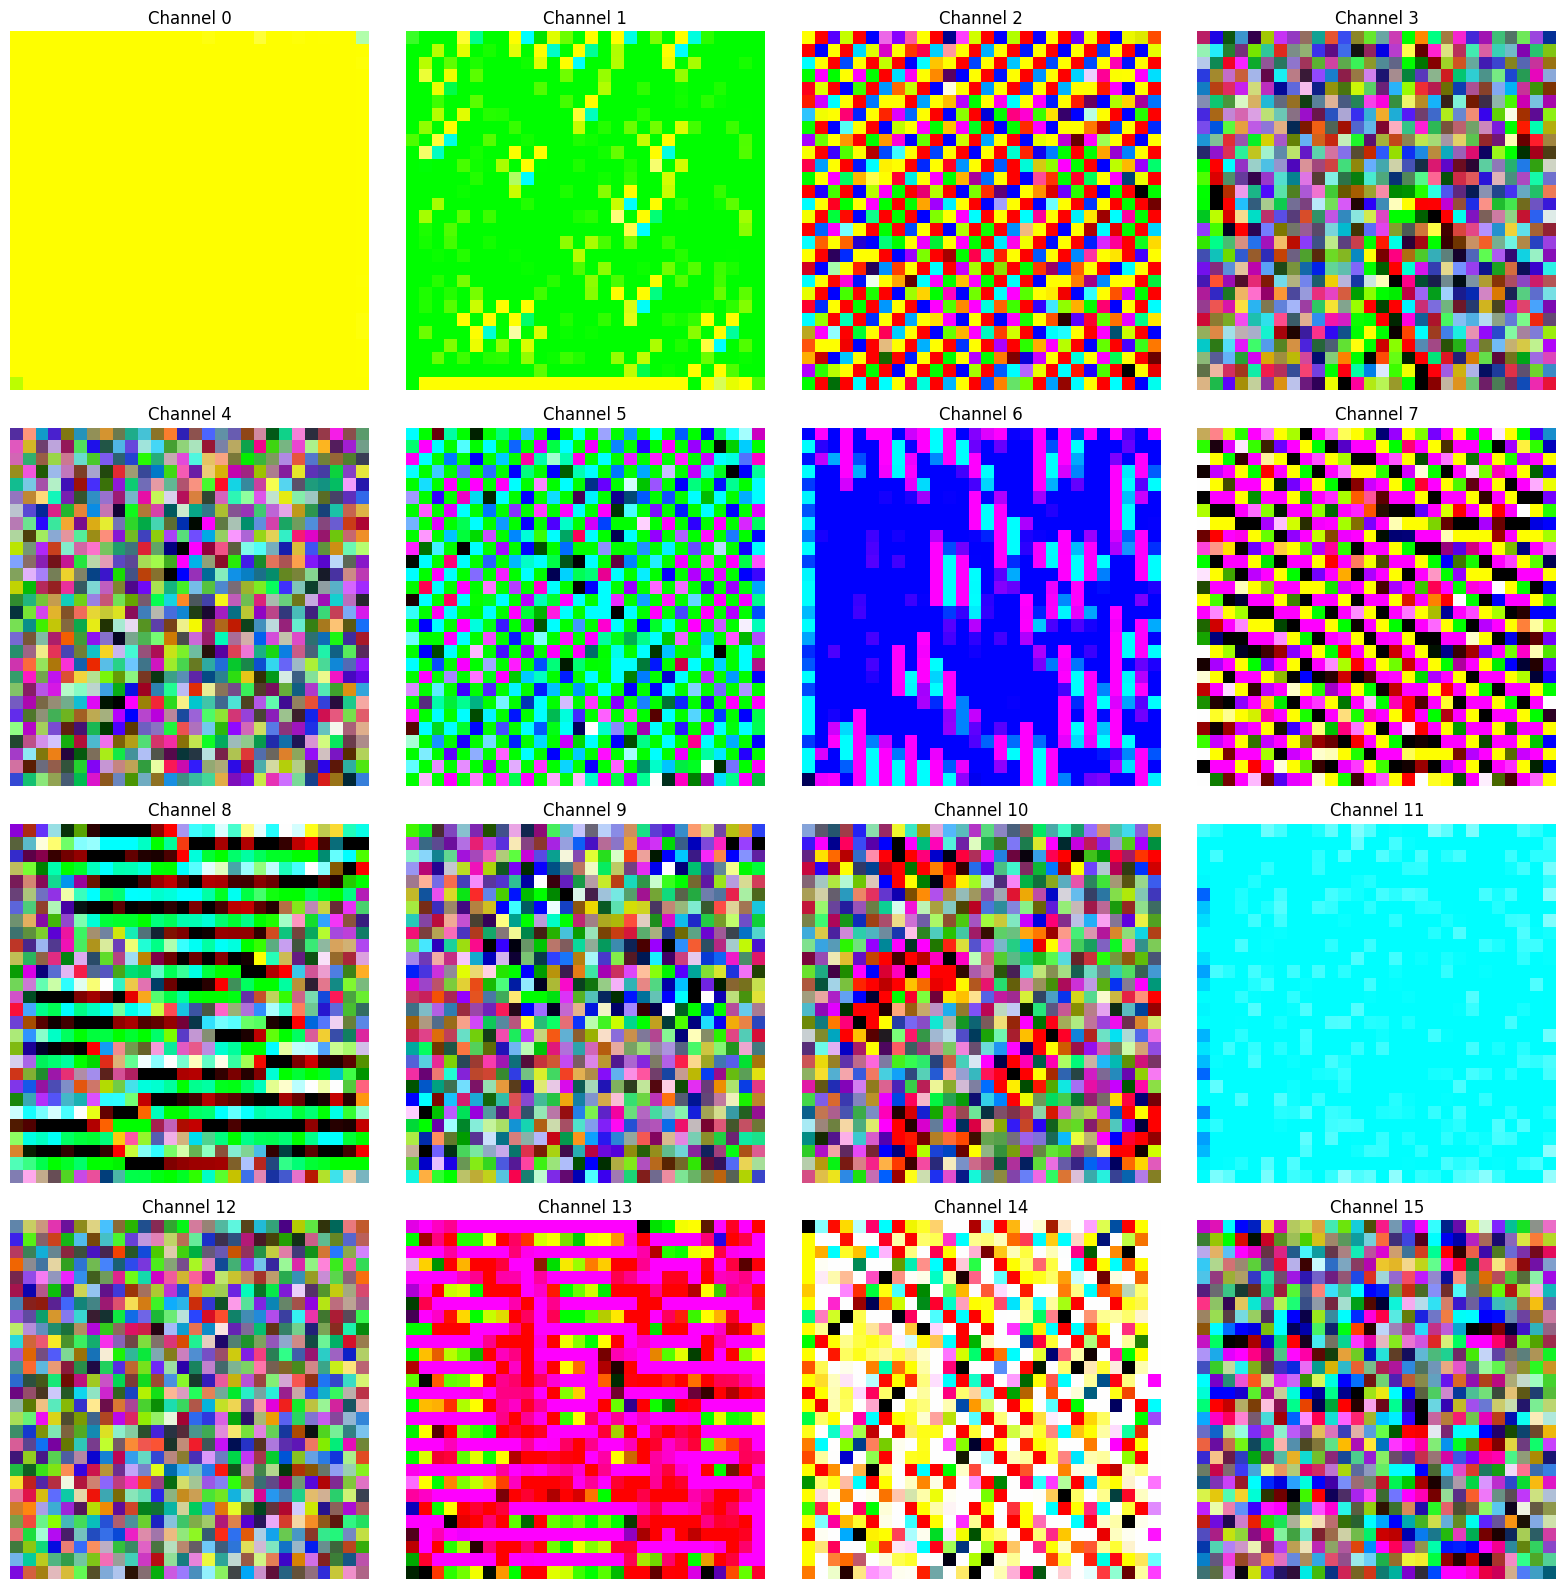

In [ ]:
import matplotlib.pyplot as plt
import math

print(f"Total channels: {len(all_channels)}")
print(f"Shape: {all_channels[0].shape}, Device: {all_channels[0].device}")

# Cap channels to avoid overload (adjust as needed)
max_display = 16
channels_to_plot = all_channels[:max_display]

n = len(channels_to_plot)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten() if n > 1 else [axes]

for i, channel in enumerate(channels_to_plot):
    channel = channel.detach().cpu().float()  # all at once
    channel -= channel.min()
    channel /= (channel.max() + 1e-8)

    # Handle shape dynamically
    if channel.dim() == 4:
        channel = channel.squeeze(0)   # (1,C,H,W) -> (C,H,W)
    if channel.dim() == 3:
        channel = channel.permute(1, 2, 0)  # (C,H,W) -> (H,W,C)

    channel = channel.numpy()

    axes[i].imshow(channel)
    axes[i].set_title(f'Channel {i}')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Case 2: with regularization

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import numpy as np

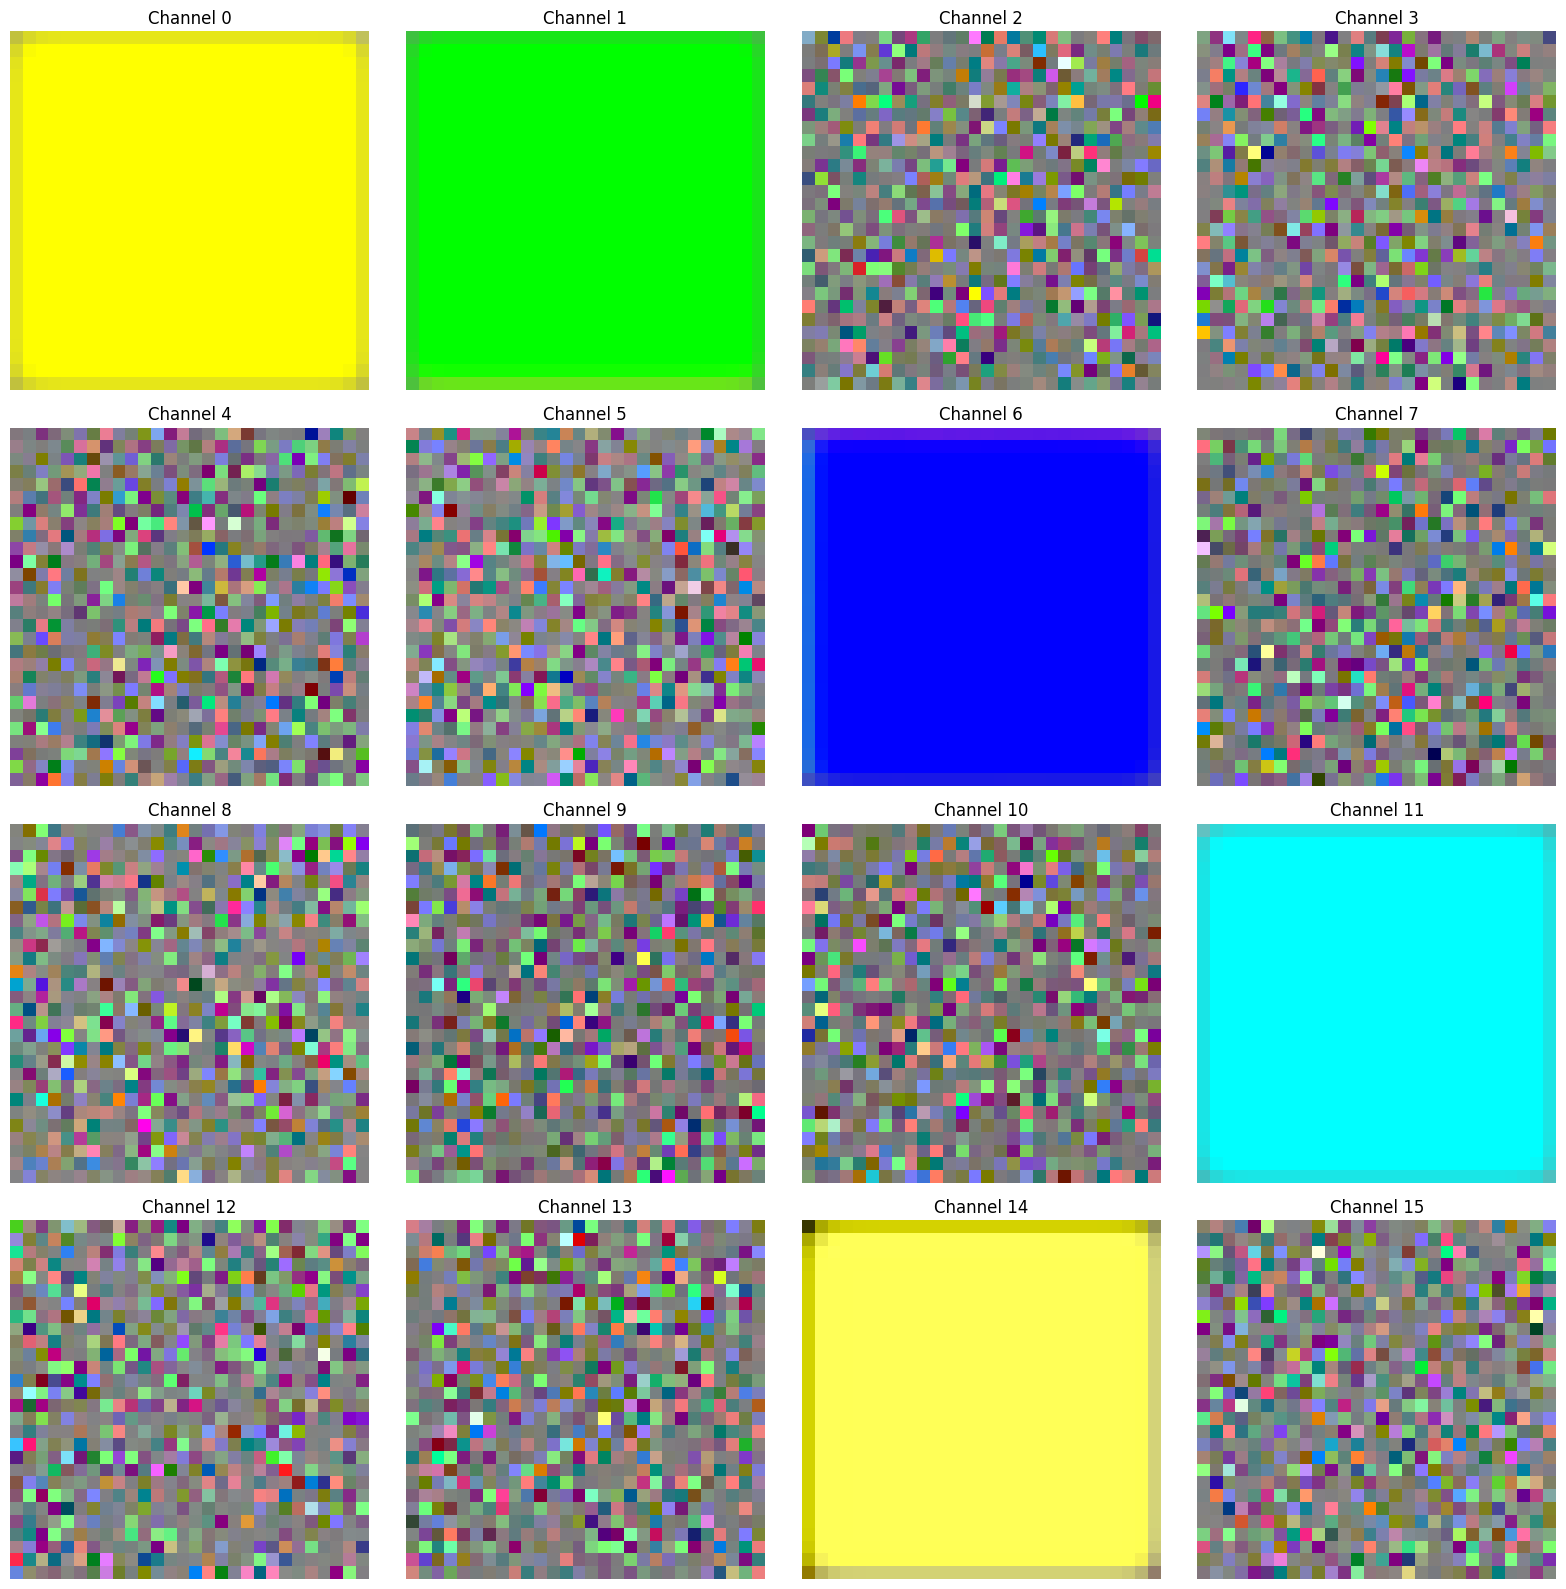

In [ ]:
def gaussian_blur(tensor, sigma=1.0, kernel_size=5):
    channels = tensor.shape[1]
    x = torch.arange(kernel_size, device=tensor.device).float() - kernel_size // 2
    kernel_1d = torch.exp(-x**2 / (2 * sigma**2))
    kernel_1d = kernel_1d / kernel_1d.sum()
    kernel_2d = kernel_1d[:, None] * kernel_1d[None, :]
    kernel_2d = kernel_2d.expand(channels, 1, kernel_size, kernel_size)
    padding = kernel_size // 2
    return F.conv2d(tensor, kernel_2d, padding=padding, groups=channels)


def activation_maximization(model, layer_name, channel_idx,
                            img_size=(3, 28, 28), steps=500, lr=0.05,
                            l2_decay=1e-4, blur_every=4, blur_sigma=1.0):
    model.eval()
    input_img = torch.randn(1, *img_size, device=next(model.parameters()).device) * 0.01
    input_img.requires_grad_(True)
    optimizer = torch.optim.Adam([input_img], lr=lr)

    activation = {}
    def hook_fn(module, inp, out):
        activation['value'] = out

    target_layer = dict(model.named_modules())[layer_name]
    handle = target_layer.register_forward_hook(hook_fn)

    for step in range(steps):
        optimizer.zero_grad()
        _ = model(input_img)
        act = activation['value']
        loss = -act[0, channel_idx].mean()
        loss += l2_decay * (input_img ** 2).sum()
        loss.backward()
        optimizer.step()

        if step % blur_every == 0:
            input_img.data = gaussian_blur(input_img.data, sigma=blur_sigma)
        input_img.data.clamp_(-1, 1)

    handle.remove()
    return input_img.detach()


# --- Run for all channels ---
layer_name = 'encoder'  # change to your target layer
max_display = 16

all_channels = []
for ch in range(max_display):
    img = activation_maximization(model, layer_name, ch)
    all_channels.append(img)

# --- Visualization (your variable names) ---
channels_to_plot = all_channels[:max_display]
n = len(channels_to_plot)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten() if n > 1 else [axes]

for i, channel in enumerate(channels_to_plot):
    channel = channel.detach().cpu().float()
    if channel.dim() == 4:
        channel = channel.squeeze(0)
    if channel.dim() == 3:
        channel = channel.permute(1, 2, 0)
    channel = channel.numpy()
    # Percentile normalization instead of min/max
    lo, hi = np.percentile(channel, 2), np.percentile(channel, 98)
    channel = (channel - lo) / (hi - lo + 1e-8)
    channel = np.clip(channel, 0, 1)

    axes[i].imshow(channel)
    axes[i].set_title(f'Channel {i}')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Task-3 The Interrogation (coding Grad CAM)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
model.encoder

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
)

In [ ]:
def forward_hook(module, inp, out):
    global activations
    activations = out

In [ ]:
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

In [ ]:
import torch.nn.functional as F

f = model.encoder.register_forward_hook(forward_hook)
b = model.encoder.register_full_backward_hook(backward_hook)


def gradcam(model, image, target_class=None):

    model.eval()

    output = model(image)
    print(output.shape)

    if target_class is None:          #if target is not specifed then chose the class having maximum logit
        target_class = output.argmax(dim=1).item()

    print(target_class)

    model.zero_grad()

    score = output[0, target_class]
    score.backward()

    A = activations[0]
    G = gradients[0]

    alpha = G.mean(dim=(1,2))   #alpha for each channel (to give weight to each feature map)

    cam = torch.zeros(A.shape[1:], device=A.device)

    for k in range(A.shape[0]):
        cam += alpha[k] * A[k]

    cam = F.relu(cam)   #heatmap showing which spatial locations in the feature maps were most important for predicting class c

    cam -= cam.min()
    cam /= (cam.max() + 1e-8)

    return cam.detach().cpu()

In [ ]:
f.remove()
b.remove()

### Baised image

In [ ]:
#baised image
for img, label, masks in train_loader:
    image1, label1 = img[0].cpu(), label[0].cpu()
    break

In [ ]:
image = image1.permute(1,2,0)

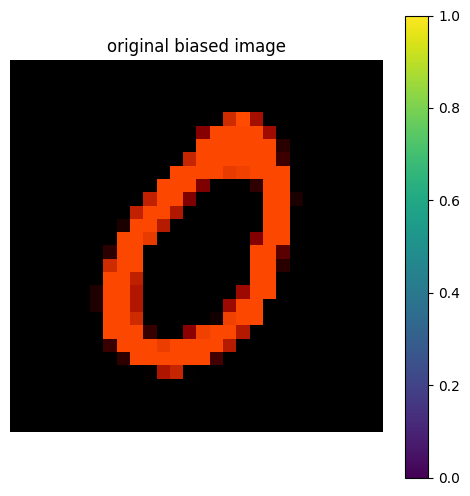

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(image, cmap='viridis')
plt.colorbar()
plt.title('original biased image')
plt.axis('off')
plt.show()

In [ ]:
a  = gradcam(model,image1.unsqueeze(dim=0).to(device))

torch.Size([1, 10])
0


In [ ]:
a.shape

torch.Size([28, 28])

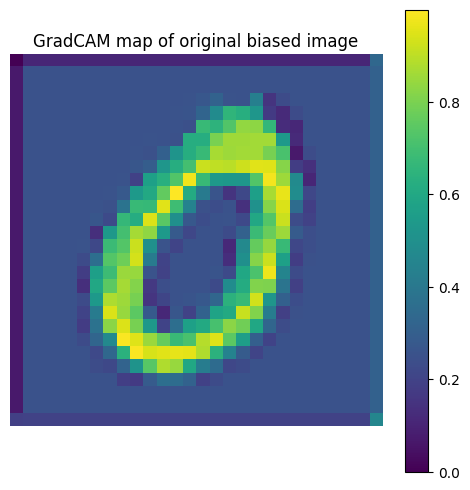

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(a, cmap='viridis')
plt.colorbar()
plt.title('GradCAM map of original biased image')
plt.axis('off')
plt.show()

### Conflicting image

In [ ]:
for img, label, masks in test_loader:
    image2, label2 = img[0].cpu(), label[0].cpu()
    break

In [ ]:
image = image2.permute(1,2,0)

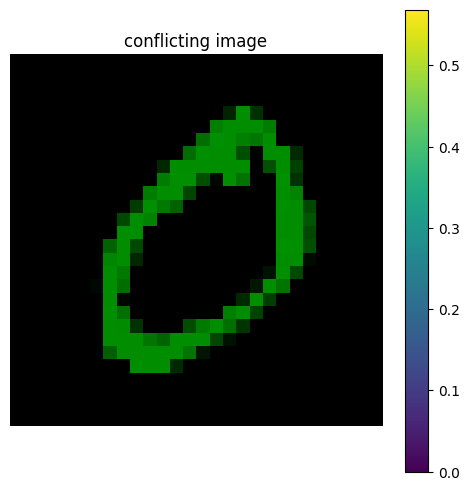

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(image, cmap='viridis')
plt.colorbar()
plt.title('conflicting image')
plt.axis('off')
plt.show()

In [ ]:
a = gradcam(model,image2.unsqueeze(dim=0).to(device))

torch.Size([1, 10])
3


In [ ]:
a.shape

torch.Size([28, 28])

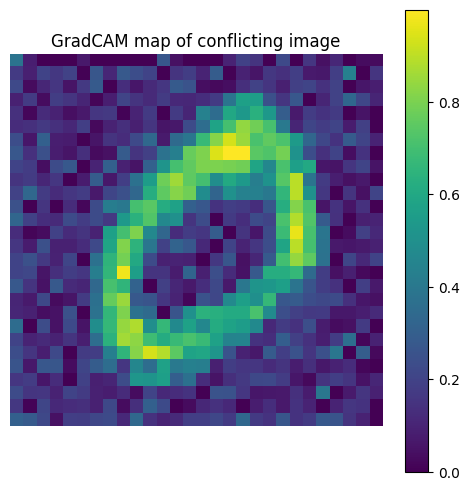

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(a, cmap='viridis')
plt.colorbar()
plt.title('GradCAM map of conflicting image')
plt.axis('off')
plt.show()

## Task 4- Intervention (re-training to avoid cheating)


### extra

In [7]:
import os
import random
from collections import defaultdict
from pathlib import Path
from torchvision import transforms
import torch.nn as nn
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [8]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

In [9]:
device

device(type='cuda')

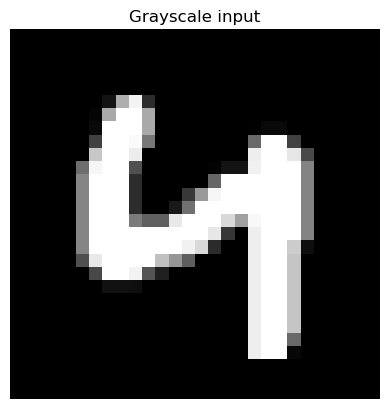

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_masked_image(dataset, idx=0):
    """
    Shows 3 panels for a single sample:
    - Original colored image
    - Mask (1=background, 0=foreground)
    - Masked image (background zeroed out)
    """
    # raw numpy arrays — before any transform
    img  = dataset.images[idx]          # (28, 28, 3) uint8
    mask = dataset.masks[idx]           # (28, 28)    float32, 1=bg, 0=fg

    gray = img.mean(axis=2)  # average across RGB channels → (28, 28)
    plt.imshow(gray, cmap='gray')
    plt.axis('off')
    plt.title('Grayscale input')
    plt.show()

# usage — pass the raw dataset object (not the DataLoader)
visualize_masked_image(full_train_ds, idx=214)

### Method 1:  RRR - penalizing the entire masked (digit) region

In [ ]:
##method 1: right for right reasons

import csv

def train(model, train_loader, val_loader, epochs=20, lr=1e-3, lambda1=100, lambda2=0.0001,
          log_path="./training_logs/training_logs_method1.csv"):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=lambda2)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    eps = 1e-8

    best_val_acc = 0.0

    # Initialize CSV log file
    with open(log_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "epoch", "train_loss", "train_acc", "val_loss", "val_acc",
            "ce_loss", "grad_penalty", "lambda_x_penalty"
        ])

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = train_correct = 0

        for imgs, labels, masks in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            masks = masks.to(device)

            imgs = imgs.detach().requires_grad_(True)

            logits = model(imgs)
            ce_loss = criterion(logits, labels)

            target_score = logits.gather(1, labels.unsqueeze(1)).mean()

            input_grad = torch.autograd.grad(target_score, imgs, create_graph=True)[0]

            grad_penalty = (input_grad * masks).pow(2).sum(dim=(1, 2, 3)).mean()

            loss = ce_loss + lambda1 * grad_penalty

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()

        scheduler.step()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss = val_correct = 0

        with torch.no_grad():
            for imgs, labels, masks in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)

                logits = model(imgs)

                val_loss += criterion(logits, labels).item() * imgs.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(
            f'Epoch {epoch:>2}/{epochs}  '
            f'train loss {train_loss:.4f} acc {train_acc:.4f}  |  '
            f'val loss {val_loss:.4f} acc {val_acc:.4f}'
        )

        print(
            f'CE={ce_loss.item():.4f}  '
            f'penalty={grad_penalty.item():.6f}  '
            f'lambda*penalty={lambda1*grad_penalty.item():.4f}'
        )

        # Append to CSV
        with open(log_path, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch, f"{train_loss:.6f}", f"{train_acc:.6f}",
                f"{val_loss:.6f}", f"{val_acc:.6f}",
                f"{ce_loss.item():.6f}", f"{grad_penalty.item():.8f}",
                f"{lambda1 * grad_penalty.item():.6f}"
            ])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "./trained_models/best_retrained_model_method1.pth")

if __name__ == '__main__':
    model1 = Cheater()
    # model.load_state_dict(torch.load("/content/drive/MyDrive/precog_assignment/trained_models/best_CNNmodel.pth"))
    model1 = model.to(device)
    train(model1, train_loader, val_loader)

Epoch  1/20  train loss 0.0032 acc 0.9994  |  val loss 0.0005 acc 0.9998
CE=0.0003  penalty=0.000607  lambda*penalty=0.0607
Epoch  2/20  train loss 0.0008 acc 1.0000  |  val loss 0.0006 acc 0.9997
CE=0.0001  penalty=0.000288  lambda*penalty=0.0288
Epoch  3/20  train loss 0.0100 acc 0.9983  |  val loss 0.0002 acc 1.0000
CE=0.0001  penalty=0.002162  lambda*penalty=0.2162
Epoch  4/20  train loss 0.0020 acc 0.9999  |  val loss 0.0004 acc 0.9999
CE=0.0000  penalty=0.000796  lambda*penalty=0.0796
Epoch  5/20  train loss 0.0007 acc 1.0000  |  val loss 0.0003 acc 0.9999
CE=0.0001  penalty=0.000243  lambda*penalty=0.0243
Epoch  6/20  train loss 0.0005 acc 1.0000  |  val loss 0.0004 acc 0.9999
CE=0.0001  penalty=0.000263  lambda*penalty=0.0263
Epoch  7/20  train loss 0.0005 acc 1.0000  |  val loss 0.0002 acc 0.9999
CE=0.0001  penalty=0.000383  lambda*penalty=0.0383
Epoch  8/20  train loss 0.0006 acc 1.0000  |  val loss 0.0002 acc 1.0000
CE=0.0001  penalty=0.000130  lambda*penalty=0.0130
Epoch  9

In [12]:
# model.load_state_dict(torch.load('/content/drive/MyDrive/CNNmodel_retrained.pth'))
# model = model.to(device)

def test(model, test_loader):

    model.eval()

    total_loss = 0
    total_correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels, masks in test_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)

            total_loss += criterion(logits, labels).item() * imgs.size(0)
            total_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()

            all_preds.append(
                logits.argmax(dim=1).cpu()
            )
            all_labels.append(
                labels.cpu()
            )

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    n = len(labels)

    overall_loss = total_loss / n
    overall_acc = total_correct / n

    per_class_acc = {}

    for digit in range(10):

        class_mask = (labels == digit)

        if class_mask.sum() > 0:
            per_class_acc[digit] = (
                (preds[class_mask] ==
                 labels[class_mask])
                .float()
                .mean()
                .item()
            )
        else:
            per_class_acc[digit] = 0.0


    conf_matrix = torch.zeros(
        10,
        10,
        dtype=torch.long
    )

    for t, p in zip(labels.view(-1), preds.view(-1)):
        conf_matrix[t.long(), p.long()] += 1

    print(
        f'\nTest loss: {overall_loss:.4f}'
        f' | Test accuracy: {overall_acc:.4f}\n'
    )

    print('Per-class accuracy:')

    for digit, acc in per_class_acc.items():

        bar = '█' * int(acc * 20)

        print(
            f'  Digit {digit}: '
            f'{acc:.4f} {bar}'
        )

    print('\nConfusion matrix (rows=true, cols=pred):')

    header = '       ' + '  '.join(
        f'{i:>4}' for i in range(10)
    )
    print(header)

    for i, row in enumerate(conf_matrix):
        print(
            f' [{i}]  ' +
            '  '.join(
                f'{v:>4}'
                for v in row.tolist()
            )
        )

    return {
        'loss': overall_loss,
        'accuracy': overall_acc,
        'per_class_acc': per_class_acc,
        'conf_matrix': conf_matrix,
    }

In [ ]:
results = test(model1, test_loader)

# results dict for further use
print(results['accuracy'])
print(results['per_class_acc'])
print(results['conf_matrix'])


Test loss: 40.5854 | Test accuracy: 0.0537

Per-class accuracy:
  Digit 0: 0.0000 
  Digit 1: 0.0000 
  Digit 2: 0.0000 
  Digit 3: 0.0000 
  Digit 4: 0.0000 
  Digit 5: 0.0443 
  Digit 6: 0.0000 
  Digit 7: 0.2300 ████
  Digit 8: 0.1058 ██
  Digit 9: 0.1549 ███

Confusion matrix (rows=true, cols=pred):
          0     1     2     3     4     5     6     7     8     9
 [0]     0     4    35    42     6    36     1    59    49    64
 [1]     0     0    28    13     0    53     0   131    20    92
 [2]     1     4     0    22     7    36     8    89    59    72
 [3]     3     3    40     0     2    50     0    91    55    63
 [4]     0     0    32    20     0    38     0    68    63    71
 [5]     0     1    25    28     1    12     1    88    42    73
 [6]     0     3    25    22    17    42     0    97    54    36
 [7]     0     0    30    21     4    41     0    72    64    81
 [8]     3     1    39    27    11    35     0    88    31    58
 [9]     0     0    43    28     4    44   

### Method 2: Penalizing the colour deviation only

In [33]:
##method 2:

import csv

def train(model, train_loader, val_loader, epochs=20, lr=5e-3, lambda1=0.8, lambda2=0.0001,
          log_path="./logs/training_logs_method2_lr5e-3_lamb0.8.csv"):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=lambda2)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    eps = 1e-8

    with open(log_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "epoch", "train_loss", "train_acc", "val_loss", "val_acc",
            "ce_loss", "grad_penalty", "lambda_x_penalty",
            "grad_R", "grad_G", "grad_B"
        ])

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = train_correct = 0

        for imgs, labels, masks in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            masks = masks.to(device)

            imgs = imgs.detach().requires_grad_(True)

            logits = model(imgs)
            ce_loss = criterion(logits, labels)

            target_score = logits.gather(1, labels.unsqueeze(1)).mean()

            input_grad = torch.autograd.grad(target_score, imgs, create_graph=True)[0]

            digit_mask = masks
            digit_grad = input_grad * digit_mask

            grad_norm = digit_grad.norm(p=2, dim=1, keepdim=True) + eps
            digit_grad = digit_grad / grad_norm

            channel_mean = digit_grad.mean(dim=1, keepdim=True)
            color_deviation = digit_grad - channel_mean

            grad_penalty = color_deviation.pow(2).sum(dim=(1, 2, 3)).mean()

            loss = ce_loss + lambda1 * grad_penalty

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()

        scheduler.step()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss = val_correct = 0

        with torch.no_grad():
            for imgs, labels, masks in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)

                logits = model(imgs)

                val_loss += criterion(logits, labels).item() * imgs.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        with torch.no_grad():
            r = digit_grad[:, 0].abs().mean().item()
            g = digit_grad[:, 1].abs().mean().item()
            b = digit_grad[:, 2].abs().mean().item()

        print(
            f'Epoch {epoch:>2}/{epochs}  '
            f'train loss {train_loss:.4f} acc {train_acc:.4f}  |  '
            f'val loss {val_loss:.4f} acc {val_acc:.4f}'
        )
        print(
            f'CE={ce_loss.item():.4f}  '
            f'penalty={grad_penalty.item():.6f}  '
            f'lambda*penalty={lambda1*grad_penalty.item():.4f}'
        )
        print(
            f'RGB gradient magnitude: '
            f'R={r:.4f} G={g:.4f} B={b:.4f}'
        )

        with open(log_path, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch, f"{train_loss:.6f}", f"{train_acc:.6f}",
                f"{val_loss:.6f}", f"{val_acc:.6f}",
                f"{ce_loss.item():.6f}", f"{grad_penalty.item():.8f}",
                f"{lambda1 * grad_penalty.item():.6f}",
                f"{r:.6f}", f"{g:.6f}", f"{b:.6f}"
            ])

if __name__ == '__main__':
    model2 = Cheater()
    model2 = model2.to(device)
    train(model2, train_loader, val_loader)
    torch.save(model2.state_dict(), "./trained_models/CNNmodel_retrained_method2_lr5e-3_lamb0.8.pth")

Epoch  1/20  train loss 4.3319 acc 0.6677  |  val loss 2.2146 acc 0.3136
CE=0.7486  penalty=0.418658  lambda*penalty=0.3349
RGB gradient magnitude: R=0.1091 G=0.1100 B=0.1099
Epoch  2/20  train loss 1.1978 acc 0.7667  |  val loss 0.5426 acc 0.8234
CE=0.5092  penalty=0.766893  lambda*penalty=0.6135
RGB gradient magnitude: R=0.1102 G=0.1119 B=0.1111
Epoch  3/20  train loss 1.1662 acc 0.7869  |  val loss 1.0244 acc 0.6948
CE=0.5327  penalty=0.388599  lambda*penalty=0.3109
RGB gradient magnitude: R=0.1032 G=0.1028 B=0.1029
Epoch  4/20  train loss 1.1006 acc 0.7930  |  val loss 0.8170 acc 0.7875
CE=0.6222  penalty=0.388585  lambda*penalty=0.3109
RGB gradient magnitude: R=0.1120 G=0.1114 B=0.1113
Epoch  5/20  train loss 1.0322 acc 0.7482  |  val loss 0.7169 acc 0.7685
CE=0.8553  penalty=0.212522  lambda*penalty=0.1700
RGB gradient magnitude: R=0.1188 G=0.1177 B=0.1189
Epoch  6/20  train loss 0.9635 acc 0.7629  |  val loss 0.8181 acc 0.7476
CE=1.1027  penalty=0.234594  lambda*penalty=0.1877
R

In [ ]:
# model.load_state_dict(torch.load('/content/drive/MyDrive/CNNmodel_retrained.pth'))
# model = model.to(device)

def test(model, test_loader):

    model.eval()

    total_loss = 0
    total_correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels, masks in test_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)

            total_loss += criterion(logits, labels).item() * imgs.size(0)
            total_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()

            all_preds.append(
                logits.argmax(dim=1).cpu()
            )
            all_labels.append(
                labels.cpu()
            )

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    n = len(labels)

    overall_loss = total_loss / n
    overall_acc = total_correct / n

    per_class_acc = {}

    for digit in range(10):

        class_mask = (labels == digit)

        if class_mask.sum() > 0:
            per_class_acc[digit] = (
                (preds[class_mask] ==
                 labels[class_mask])
                .float()
                .mean()
                .item()
            )
        else:
            per_class_acc[digit] = 0.0


    conf_matrix = torch.zeros(
        10,
        10,
        dtype=torch.long
    )

    for t, p in zip(labels.view(-1), preds.view(-1)):
        conf_matrix[t.long(), p.long()] += 1

    print(
        f'\nTest loss: {overall_loss:.4f}'
        f' | Test accuracy: {overall_acc:.4f}\n'
    )

    print('Per-class accuracy:')

    for digit, acc in per_class_acc.items():

        bar = '█' * int(acc * 20)

        print(
            f'  Digit {digit}: '
            f'{acc:.4f} {bar}'
        )

    print('\nConfusion matrix (rows=true, cols=pred):')

    header = '       ' + '  '.join(
        f'{i:>4}' for i in range(10)
    )
    print(header)

    for i, row in enumerate(conf_matrix):
        print(
            f' [{i}]  ' +
            '  '.join(
                f'{v:>4}'
                for v in row.tolist()
            )
        )

    return {
        'loss': overall_loss,
        'accuracy': overall_acc,
        'per_class_acc': per_class_acc,
        'conf_matrix': conf_matrix,
    }

In [34]:
results = test(model2, test_loader)

# results dict for further use
print(results['accuracy'])
print(results['per_class_acc'])
print(results['conf_matrix'])


Test loss: 14.9858 | Test accuracy: 0.1103

Per-class accuracy:
  Digit 0: 0.0507 █
  Digit 1: 0.0000 
  Digit 2: 0.0000 
  Digit 3: 0.0000 
  Digit 4: 0.0000 
  Digit 5: 0.0000 
  Digit 6: 0.0101 
  Digit 7: 1.0000 ████████████████████
  Digit 8: 0.0000 
  Digit 9: 0.0000 

Confusion matrix (rows=true, cols=pred):
          0     1     2     3     4     5     6     7     8     9
 [0]    15     0     0     0     0     0     0   281     0     0
 [1]     0     0     0     0     0     0     0   337     0     0
 [2]    18     0     0     0     0     0     4   276     0     0
 [3]     8     0     0     0     0     0     0   299     0     0
 [4]     0     0     0     0     0     0     0   291     0     1
 [5]     3     0     0     0     0     0     0   268     0     0
 [6]     2     0     0     0     0     0     3   291     0     0
 [7]     0     0     0     0     0     0     0   313     0     0
 [8]     0     0     0     0     0     0     0   293     0     0
 [9]     0     0     0     0   

In [46]:
all_channels = []

for c in range(16):
  random_img = torch.empty(
        1,3,28,28,
        device=device
    ).uniform_(-1,1)

  random_img.requires_grad_(True)

  lr = 0.05

  s_model.eval()

  # for p in model.parameters():
  #     p.requires_grad = False

  for i in range(50000):
    features = s_model.encoder(random_img)

    activation = features[:,c,:,:].mean() #mean(summary) of feature map 9

    activation.backward() #finds d(activation)/d(random_img) which tell us how much each pixel is contributing to this feature map

    # print(activation)

    with torch.no_grad():
        random_img.clamp_(-1,1)
        # print(random_img.grad)
        random_img += lr * random_img.grad  #gradient tell us how of the colour to add (the amount of change of the highly contributing pixels is sharp)

    random_img.grad.zero_()

  all_channels.append(random_img)

    # print(i, activation.item())


Total channels: 16
Shape: torch.Size([1, 3, 28, 28]), Device: cuda:0


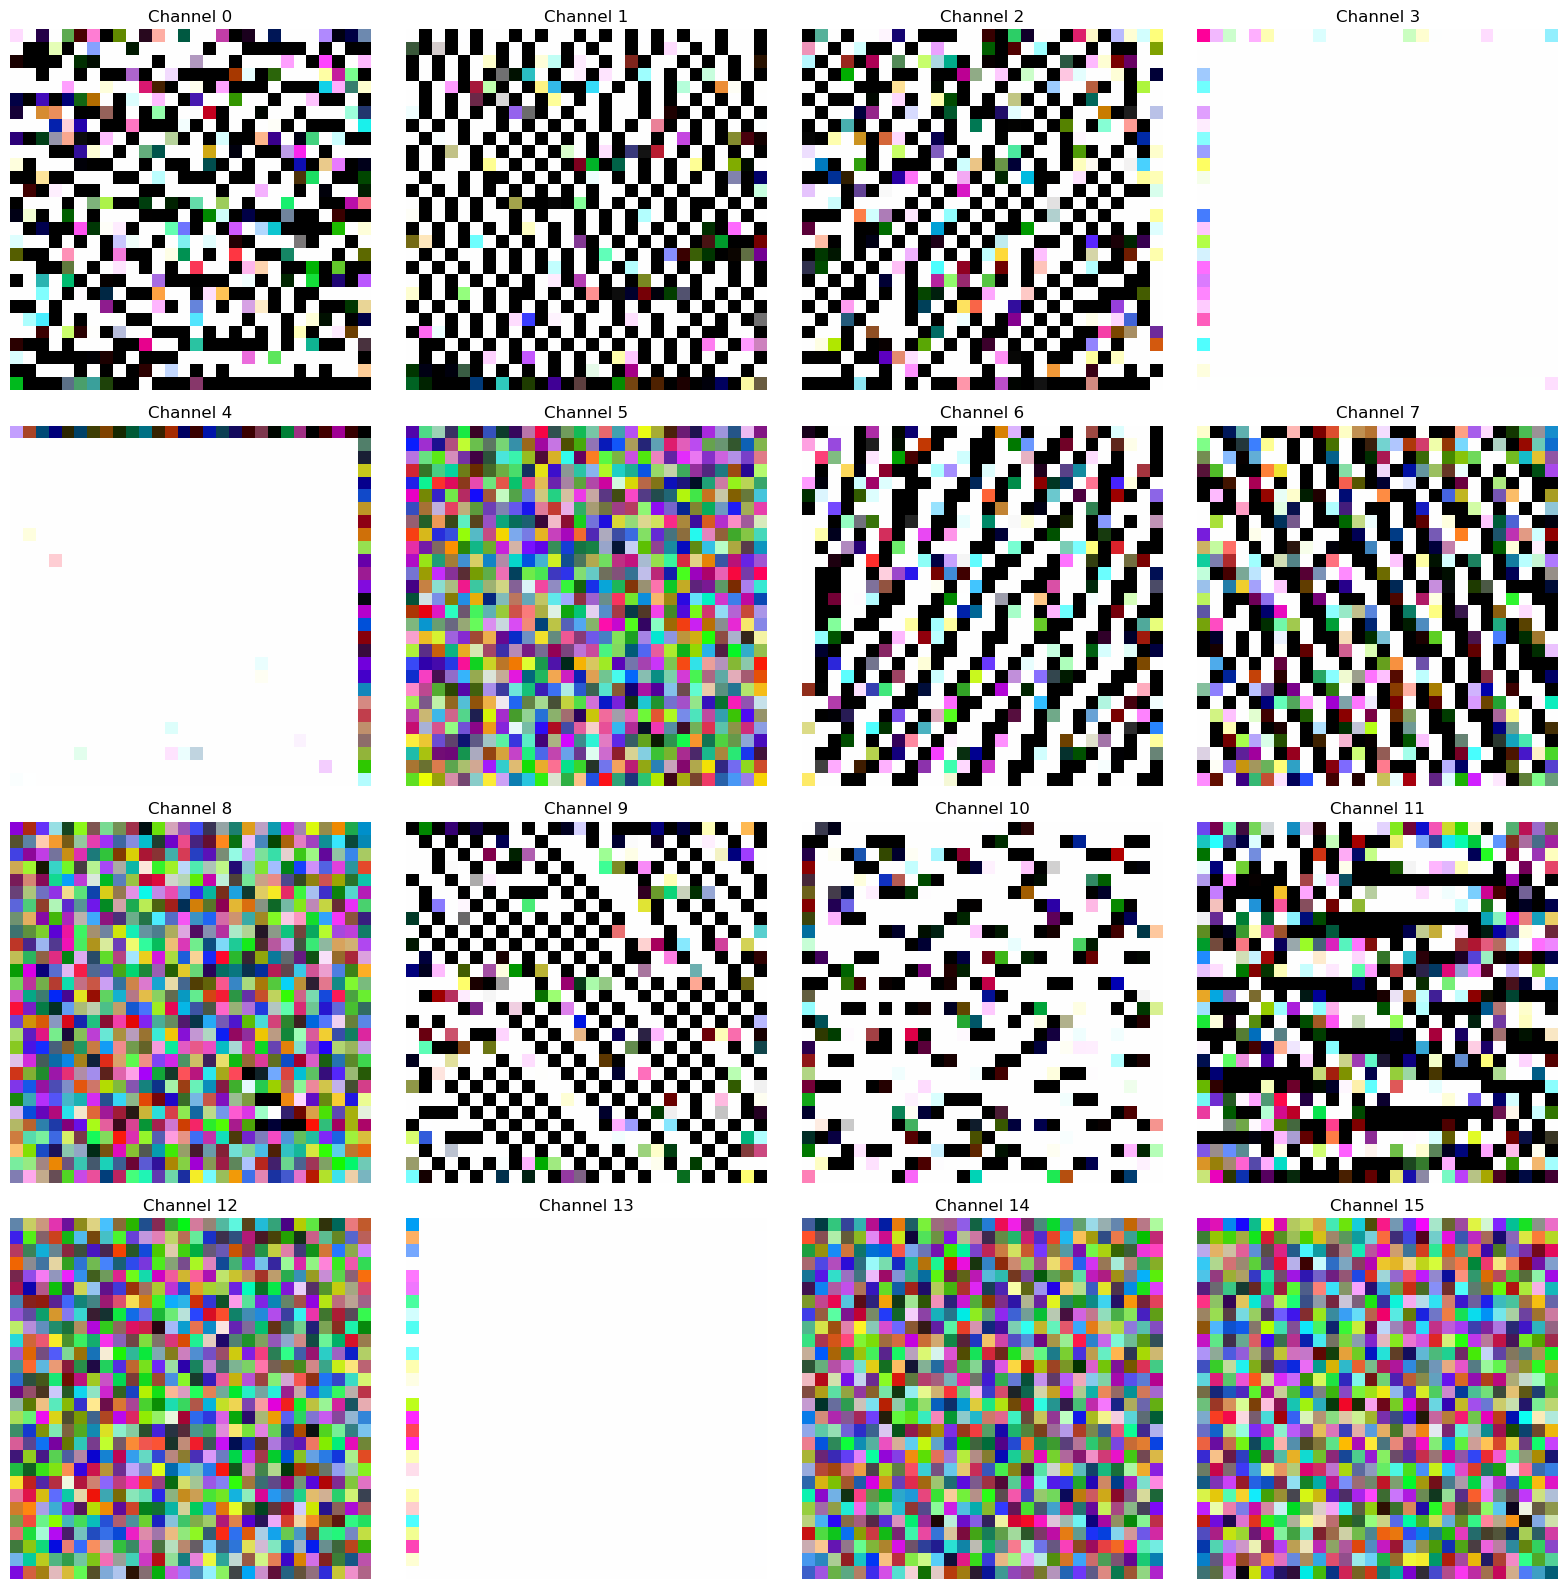

In [47]:
import matplotlib.pyplot as plt
import math

# Quick sanity check
print(f"Total channels: {len(all_channels)}")
print(f"Shape: {all_channels[0].shape}, Device: {all_channels[0].device}")

# Cap channels to avoid overload (adjust as needed)
max_display = 16
channels_to_plot = all_channels[:max_display]

n = len(channels_to_plot)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten() if n > 1 else [axes]

for i, channel in enumerate(channels_to_plot):
    channel = channel.detach().cpu().float()  # all at once
    channel -= channel.min()
    channel /= (channel.max() + 1e-8)

    # Handle shape dynamically
    if channel.dim() == 4:
        channel = channel.squeeze(0)   # (1,C,H,W) -> (C,H,W)
    if channel.dim() == 3:
        channel = channel.permute(1, 2, 0)  # (C,H,W) -> (H,W,C)

    channel = channel.numpy()

    axes[i].imshow(channel)
    axes[i].set_title(f'Channel {i}')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [49]:
def forward_hook(module, inp, out):
    global activations
    activations = out

In [50]:
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

In [51]:
import torch.nn.functional as F

f = s_model.encoder.register_forward_hook(forward_hook)
b = s_model.encoder.register_full_backward_hook(backward_hook)


def gradcam(model, image, target_class=None):

    model.eval()

    output = model(image)
    print(output.shape)

    if target_class is None:
        target_class = output.argmax(dim=1).item()

    print(target_class)

    model.zero_grad()

    score = output[0, target_class]
    score.backward()

    A = activations[0]
    G = gradients[0]

    alpha = G.mean(dim=(1,2))   #alpha for each channel (to give weight to each feature map)

    cam = torch.zeros(A.shape[1:], device=A.device)

    for k in range(A.shape[0]):
        cam += alpha[k] * A[k]

    cam = F.relu(cam)   #heatmap showing which spatial locations in the feature maps were most important for predicting class c

    cam -= cam.min()
    cam /= (cam.max() + 1e-8)

    return cam.detach().cpu()

In [ ]:
f.remove()
b.remove()

In [52]:
for img, label, mask in test_loader:
    image, label = img[81].to(device), label[81].to(device)
    break

In [ ]:
for img, label,mask in train_loader:
    image1, label1 = img[81].to(device), label[81].to(device)
    break

In [53]:
image = image.unsqueeze(dim=0)
image.shape

torch.Size([1, 3, 28, 28])

In [54]:
label

tensor(8, device='cuda:0')

In [55]:
a1 = gradcam(s_model, image)

torch.Size([1, 10])
2


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


In [56]:
a1.shape

torch.Size([28, 28])

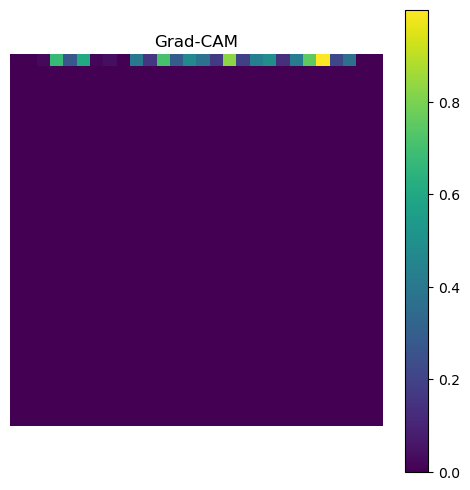

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(a1, cmap='viridis')
plt.colorbar()
plt.title('Grad-CAM')
plt.axis('off')
plt.show()

### Method 3: Learning not to Learn (training bias predictor to minimize the target bias from feature representation)
![text](./Screenshot%20from%202026-07-05%2019-48-59.png)

#### dataset to train bias predictor classifier 

In [169]:
import os
import random
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
class ColoredMNIST(Dataset):
    """
    Colored MNIST with a clean majority/minority split.

    Source : MNIST train set (60,000 samples).
    Split  :
        split='train' → majority only (~57,000)  assigned color, black background.
        split='test'  → minority only  (~3,000)  different color, noisy background.

    No minority samples appear in train. No majority samples appear in test.
    """

    def __init__(
        self,
        root: str            = './data_for_method3',
        split: str           = 'train',
        majority_frac: float = 0.95,
        seed: int            = 42,
        transform            = None,
        mask_threshold: int  = 10,       # NEW — pixels <= threshold are background
    ):
        assert split in ('train', 'test'), "split must be 'train' or 'test'"

        self.majority_frac = majority_frac
        self.transform     = transform

        raw    = datasets.MNIST(root=root, train=True, download=True)
        images = raw.data.numpy()
        labels = raw.targets.numpy()

        sample_colors, color_labels, is_majority = self._assign_colors(labels, majority_frac, seed)
        colored                    = self._build_all(images, sample_colors, is_majority, seed)

        mask             = is_majority if split == 'train' else ~is_majority
        self.images      = images[mask]
        self.labels      = labels[mask]
        self.colored     = colored[mask]
        self.color_labels = color_labels[mask]
        self.is_majority = is_majority[mask]

        # NEW — generate binary mask from raw grayscale

        self.masks = (self.images > mask_threshold).astype(np.float32)  # masking the digit

        print(f'[ColoredMNIST] {split:5s} split → {mask.sum():,} samples '
              f'({"majority" if split == "train" else "minority"})')

    # ── color assignment ──────────────────────────────────────────────────────

    @staticmethod
    def _assign_colors(labels, majority_frac, seed):
        rng           = random.Random(seed)
        n             = len(labels)
        sample_colors = [None] * n
        is_majority   = np.zeros(n, dtype=bool)
        color_labels  = np.zeros(n, dtype=np.int64)

        by_digit = defaultdict(list)
        for idx, lbl in enumerate(labels):
            by_digit[int(lbl)].append(idx)

        for digit, indices in by_digit.items():
            shuffled = indices[:]
            rng.shuffle(shuffled)
            n_maj = round(len(shuffled) * majority_frac)

            for i, idx in enumerate(shuffled):
                if i < n_maj:
                    sample_colors[idx] = DIGIT_COLORS[digit]
                    color_labels[idx]  = COLOR_TO_ID[DIGIT_COLORS[digit]]
                    is_majority[idx]   = True
                else:
                    
                    others = [c for d, c in DIGIT_COLORS.items() if d != digit]
                    chosen = rng.choice(others)

                    sample_colors[idx] = chosen
                    color_labels[idx]  = COLOR_TO_ID[chosen]

        return sample_colors, color_labels, is_majority

    # ── colorization ──────────────────────────────────────────────────────────

    @staticmethod
    def _colorize(gray, fg_color, noisy_bg, rng):
        t  = gray.astype(np.float32) / 255.0
        fg = np.array(fg_color, dtype=np.float32) / 255.0

        if noisy_bg:
            noise = rng.normal(0.12, 0.07, (*gray.shape, 3)).clip(0.0, 1.0)
            bg    = (noise + fg * 0.20).clip(0.0, 1.0)
        else:
            bg = np.zeros((*gray.shape, 3), dtype=np.float32)

        rgb = bg * (1.0 - t[..., None]) + fg * t[..., None]
        return (rgb * 255).clip(0, 255).astype(np.uint8)

    @staticmethod
    def _build_all(images, sample_colors, is_majority, seed):
        rng = np.random.default_rng(seed)
        out = np.empty((len(images), 28, 28, 3), dtype=np.uint8)
        for i in range(len(images)):
            out[i] = ColoredMNIST._colorize(
                images[i], sample_colors[i],
                noisy_bg=not is_majority[i],
                rng=rng,
            )
        return out

    # ── Dataset interface ─────────────────────────────────────────────────────

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.colored[idx]
        if self.transform:
            img = self.transform(Image.fromarray(img))
        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        return (img, int(self.labels[idx]), int(self.color_labels[idx]))

    # ── visualization ─────────────────────────────────────────────────────────

    def visualize(self, n_samples: int = 10, save_path: str = 'colored_mnist.png') -> None:
        import matplotlib.pyplot as plt

        by_digit = defaultdict(list)
        for i, lbl in enumerate(self.labels):
            by_digit[int(lbl)].append(i)

        rng  = random.Random(0)
        fig, axes = plt.subplots(
            10, n_samples,
            figsize=(n_samples * 0.7, 10 * 0.9),
            gridspec_kw={'wspace': 0.05, 'hspace': 0.1},
        )
        color = '#2ecc71' if self.is_majority.all() else '#e74c3c'

        for digit in range(10):
            samples = rng.sample(by_digit[digit], min(n_samples, len(by_digit[digit])))
            for col, idx in enumerate(samples):
                ax = axes[digit][col]
                ax.imshow(self.colored[idx])
                ax.set_xticks([]); ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_edgecolor(color); spine.set_linewidth(1.5)
            axes[digit][0].set_ylabel(str(digit), fontsize=11, rotation=0,
                                      labelpad=8, va='center')

        split_label = 'Train — majority (assigned color, clean bg)' \
                      if self.is_majority.all() else \
                      'Test — minority (different color, noisy bg)'
        fig.suptitle(split_label, fontsize=10, y=1.01)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f'Saved → {save_path}')

    # ── drive persistence ─────────────────────────────────────────────────────

    def save_to_drive(self, drive_path: str, split: str = 'train') -> None:
        if os.path.exists('/content'):
            try:
                from google.colab import drive as _drive
                if not os.path.ismount('/content/drive'):
                    _drive.mount('/content/drive')
            except ImportError:
                pass

        dest_dir  = Path(drive_path)
        dest_dir.mkdir(parents=True, exist_ok=True)
        dest_file = dest_dir / f'{split}.npz'

        np.savez_compressed(
                dest_file,
                images=self.colored,
                labels=self.labels,
                color_labels=self.color_labels,
                is_majority=self.is_majority,
                masks=self.masks,
        )
        size_mb = dest_file.stat().st_size / 1024 ** 2
        print(f'Saved {split} → {dest_file}  ({size_mb:.1f} MB, {len(self.labels):,} samples)')

    @staticmethod
    def load_from_drive(drive_path: str, split: str = 'train'):
        src = Path(drive_path) / f'{split}.npz'
        if not src.exists():
            raise FileNotFoundError(f'No saved split found at {src}')
        data = np.load(src)
        print(f'Loaded {split} ← {src}  ({len(data["labels"]):,} samples)')
        return (data['images'], data['labels'], data['color_labels'], data['is_majority'],data['masks'])


In [2]:
DIGIT_COLORS = {
    0: (255, 165,   0),   # Orange
    1: (255,   0,   0),   # Red
    2: (  0,   0, 255),   # Blue
    3: (  0, 200,   0),   # Green
    4: (220, 220,   0),   # Yellow
    5: (128,   0, 128),   # Purple
    6: (  0, 220, 220),   # Cyan
    7: (255, 105, 180),   # Hot Pink
    8: (165,  42,  42),   # Brown
    9: ( 64, 224, 208),   # Turquoise
}

COLOR_TO_ID = {
    color: idx
    for idx, color in enumerate(DIGIT_COLORS.values())
}

ID_TO_COLOR = {
    idx: color
    for color, idx in COLOR_TO_ID.items()
}

# ── usage ─────────────────────────────────────────────────────────────────────
if __name__ == '__main__':


    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,)*3, (0.5,)*3),
    ])

    train_ds = ColoredMNIST(split='train', transform=tf)   # ~57,000 majority only
    test_ds  = ColoredMNIST(split='test',  transform=tf)   # ~3,000  minority only

    train_ds.visualize(save_path='train_samples.png')
    test_ds.visualize(save_path='test_samples.png')

    drive_dir = './method3_data'
    train_ds.save_to_drive(drive_dir, split='train')
    test_ds.save_to_drive(drive_dir,  split='test')
import numpy as np
from collections import Counter

[ColoredMNIST] train split → 57,000 samples (majority)
[ColoredMNIST] test  split → 3,000 samples (minority)
Saved → train_samples.png
Saved → test_samples.png
Saved train → method3_data/train.npz  (18.3 MB, 57,000 samples)
Saved test → method3_data/test.npz  (5.9 MB, 3,000 samples)


In [171]:
class NpzDataset(Dataset):
    def __init__(self, images, labels, colour_labels, masks=None, transform=None):
        self.images    = images
        self.class_labels    = labels
        self.colour_labels = colour_labels
        self.masks     = masks
        self.transform = transform

    def __len__(self):
        return len(self.class_labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)

        if self.masks is not None:
            mask = torch.tensor(self.masks[idx], dtype=torch.float32)  # (28, 28)
            mask = mask.unsqueeze(0)                                    # (1, 28, 28)
        else:
            mask = torch.zeros(1, 28, 28)                              # fallback: all foreground

        return img, int(self.class_labels[idx]), int(self.colour_labels[idx]), mask


tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),
])

drive_dir = './method3_data'

train_images, train_labels, train_colour_labels, train_is_majority, train_masks = ColoredMNIST.load_from_drive(drive_dir, split='train')
test_images,  test_labels, test_colour_labels, _, test_masks = ColoredMNIST.load_from_drive(drive_dir, split='test')  # FIXED — unpack 4 values

full_train_ds = NpzDataset(
    images=train_images,
    labels=train_labels,
    colour_labels=train_colour_labels,
    masks=train_masks,
    transform=tf
)

val_size   = int(0.2 * len(full_train_ds))
train_size = len(full_train_ds) - val_size

train_ds, val_ds = torch.utils.data.random_split(
    full_train_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

test_loader = DataLoader(
    NpzDataset(
        images=test_images,
        labels=test_labels,
        colour_labels=test_colour_labels,
        masks=test_masks,
        transform=tf
    ),
    batch_size=256, shuffle=False, num_workers=0, pin_memory=True
)


print("Train colour label distribution:")
train_counts = Counter(train_colour_labels.tolist())
for digit in range(10):
    print(f"  Digit {digit}: {train_counts[digit]}")

print(f"\nTest colour label distribution:")
test_counts = Counter(test_colour_labels.tolist())
for digit in range(10):
    print(f"  Digit {digit}: {test_counts[digit]}")

Loaded train ← method3_data/train.npz  (57,000 samples)
Loaded test ← method3_data/test.npz  (3,000 samples)
Train colour label distribution:
  Digit 0: 5627
  Digit 1: 6405
  Digit 2: 5660
  Digit 3: 5824
  Digit 4: 5550
  Digit 5: 5150
  Digit 6: 5622
  Digit 7: 5952
  Digit 8: 5558
  Digit 9: 5652

Test colour label distribution:
  Digit 0: 303
  Digit 1: 291
  Digit 2: 297
  Digit 3: 291
  Digit 4: 300
  Digit 5: 299
  Digit 6: 312
  Digit 7: 310
  Digit 8: 295
  Digit 9: 302


In [194]:
for imgs, labels, colour_labels, _ in train_loader:
    print(colour_labels[:10])
    print(labels[:10])
    break

tensor([9, 0, 1, 1, 6, 4, 9, 2, 0, 0])
tensor([9, 0, 1, 1, 6, 4, 9, 2, 0, 0])


#### bias predictor training

In [5]:
from torch import nn

In [216]:
class Cheater(nn.Module):
    def __init__(self, input_size=28, hidden_size=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, hidden_size, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(),          
        )

        self.middle = nn.Sequential(
            nn.Conv2d(hidden_size, hidden_size * 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size * 2),
            nn.ReLU(),         
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_size * 2, hidden_size, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * input_size * input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        x = x.flatten(start_dim=1)
        x = self.classifier(x)
        return x

In [230]:
class BiasPredictor(nn.Module):
    def __init__(self, input=32, n_colors=10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(input, input, kernel_size=3,stride=1, padding=1),
            nn.BatchNorm2d(input),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Conv2d(input, n_colors, kernel_size=3,stride=1, padding=1),     #since predicting per pixel colour rather than full image
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.net(x)
        return self.classifier(x)

In [197]:
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

In [231]:
model = Cheater()
model.load_state_dict(torch.load("./trained_models/best_CNNmodel_16.pth"))
model = model.to(device)

In [233]:
def conv_hook(module, input, output):
    global activation
    activation = output
    return output

best_model_path = "./trained_models/bias_predictor.pth"

bias = BiasPredictor()
bias = bias.to(device)

criterion = nn.CrossEntropyLoss()
epochs = 20
optimizer = torch.optim.Adam(
    bias.parameters(),
    lr=1e-3,
    weight_decay=0.0001
)

hook = model.middle.register_forward_hook(conv_hook)

model.eval()

best_val_acc = 0.0

for epoch in range(1, epochs + 1):

    # ---------------- TRAIN ----------------
    bias.train()
    train_loss = 0
    train_correct = 0

    for imgs, _, colour_labels, _ in train_loader:

        imgs = imgs.to(device)
        colour_labels = colour_labels.to(device)

        with torch.no_grad():
            # enc_out = model.encoder(imgs)
            _ = model(imgs)

        features = activation.detach()

        out = bias(features)
        out_pooled = out.mean(dim=[2, 3])
        loss = criterion(out_pooled, colour_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        train_correct += (
            out_pooled.argmax(1) == colour_labels
        ).sum().item()

    train_loss /= len(train_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)

    # ---------------- VALIDATION ----------------
    bias.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():

        for imgs, _, colour_labels, _ in val_loader:

            imgs = imgs.to(device)
            colour_labels = colour_labels.to(device)

            # enc_out = model.encoder(imgs)
            _ = model(imgs)
            features = activation.detach()

            out = bias(features)
            out_pooled = out.mean(dim=[2, 3])
            val_loss += (
                criterion(out_pooled, colour_labels).item()
                * imgs.size(0)
            )

            val_correct += (
                out_pooled.argmax(1) == colour_labels
            ).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    print(
        f"Epoch {epoch}/{epochs} | "
        f"train loss {train_loss:.4f} "
        f"train acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} "
        f"val acc {val_acc:.4f}"
    )

torch.save(model.state_dict(), best_model_path)


Epoch 1/20 | train loss 1.9502 train acc 0.9656 | val loss 1.8543 val acc 0.9977
Epoch 2/20 | train loss 1.8306 train acc 0.9996 | val loss 1.8111 val acc 0.9998
Epoch 3/20 | train loss 1.8062 train acc 0.9998 | val loss 1.7963 val acc 0.9999
Epoch 4/20 | train loss 1.7939 train acc 0.9999 | val loss 1.7859 val acc 0.9999
Epoch 5/20 | train loss 1.7857 train acc 0.9999 | val loss 1.7797 val acc 0.9999
Epoch 6/20 | train loss 1.7789 train acc 0.9999 | val loss 1.7735 val acc 0.9999
Epoch 7/20 | train loss 1.7756 train acc 0.9999 | val loss 1.7715 val acc 0.9999
Epoch 8/20 | train loss 1.7711 train acc 1.0000 | val loss 1.7708 val acc 0.9999
Epoch 9/20 | train loss 1.7701 train acc 0.9996 | val loss 1.7637 val acc 0.9999
Epoch 10/20 | train loss 1.7648 train acc 0.9999 | val loss 1.7593 val acc 0.9999
Epoch 11/20 | train loss 1.7621 train acc 0.9999 | val loss 1.7577 val acc 0.9999
Epoch 12/20 | train loss 1.7599 train acc 0.9999 | val loss 1.7568 val acc 0.9999
Epoch 13/20 | train loss 

In [227]:
hook.remove()

In [228]:
def test(model, bias_model, test_loader):

    criterion = nn.CrossEntropyLoss()
    total_loss = 0
    total_correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, _, colour_labels, _ in test_loader:

            imgs = imgs.to(device)
            colour_labels = colour_labels.to(device)

            # populate global activation via hook
            # enc_out = model.middle(imgs)
            _ = model(imgs)

            features = activation.detach()

            out = bias_model(features)
            out_pooled = out.mean(dim=[2, 3])
            total_loss += (
                criterion(out_pooled, colour_labels).item()
                * imgs.size(0)
            )

            preds = out_pooled.argmax(1)

            total_correct += (
                preds == colour_labels
            ).sum().item()

            all_preds.append(preds.cpu())
            all_labels.append(colour_labels.cpu())

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    n = len(labels)

    overall_loss = total_loss / n
    overall_acc = total_correct / n

    # per-class accuracy
    per_class_acc = {}

    for c in range(10):

        mask = labels == c

        if mask.sum() > 0:
            per_class_acc[c] = (
                (preds[mask] == labels[mask])
                .float()
                .mean()
                .item()
            )
        else:
            per_class_acc[c] = 0.0

    # confusion matrix
    conf_matrix = torch.zeros(
        10, 10,
        dtype=torch.long
    )

    for t, p in zip(labels, preds):
        conf_matrix[t, p] += 1

    # print results
    print(
        f"\nTest loss: {overall_loss:.4f}"
        f" | Test accuracy: {overall_acc:.4f}\n"
    )

    print("Per-color accuracy:")

    for colour, acc in per_class_acc.items():
        bar = "█" * int(acc * 20)
        print(
            f"  Color {colour}: "
            f"{acc:.4f} {bar}"
        )

    print("\nConfusion matrix")
    print("(rows=true, cols=pred):")

    header = "       " + " ".join(
        f"{i:>4}" for i in range(10)
    )
    print(header)

    for i, row in enumerate(conf_matrix):
        print(
            f"[{i}] "
            + " ".join(
                f"{v:>4}" for v in row.tolist()
            )
        )

    return {
        "loss": overall_loss,
        "accuracy": overall_acc,
        "per_class_acc": per_class_acc,
        "conf_matrix": conf_matrix,
    }

In [232]:
model.eval()
bias.eval()

hook = model.middle.register_forward_hook(conv_hook)

results = test(model, bias, test_loader)

# results dict for further use
print(results['accuracy'])
print(results['per_class_acc'])
print(results['conf_matrix'])


Test loss: 2.0717 | Test accuracy: 0.3863

Per-color accuracy:
  Color 0: 0.0000 
  Color 1: 0.0000 
  Color 2: 0.0000 
  Color 3: 0.0000 
  Color 4: 0.0100 
  Color 5: 1.0000 ████████████████████
  Color 6: 0.0032 
  Color 7: 1.0000 ████████████████████
  Color 8: 0.8271 ████████████████
  Color 9: 1.0000 ████████████████████

Confusion matrix
(rows=true, cols=pred):
          0    1    2    3    4    5    6    7    8    9
[0]    0    0    0    0    0    0    0  303    0    0
[1]    0    0    0    0    0    0    0    0  291    0
[2]    0    0    0    0    0  297    0    0    0    0
[3]    0    0    0    0    0    0    0    0    0  291
[4]    0    0    0    0    3    0    0  233    0   64
[5]    0    0    0    0    0  299    0    0    0    0
[6]    0    0    0    0    0  269    1    0    0   42
[7]    0    0    0    0    0    0    0  310    0    0
[8]    0    0    0    0    0    0    0   51  244    0
[9]    0    0    0    0    0    0    0    0    0  302
0.3863333333333333
{0: 0.0, 1: 

In [21]:
h.remove

<bound method RemovableHandle.remove of <torch.utils.hooks.RemovableHandle object at 0x74bd5bfb68b0>>

#### unbiased model training
changing the upstream weights of feature extractor until the activation pattern that previously encoded color no longer exists in the learned representation. The feature extractor tries to maximize the bias predictors loss whereas bias predictor is trying hard to minimize its loss. the bias model and feature extractor need separate update steps with opposing goals.

In [66]:
class Cheater(nn.Module):
    def __init__(self, input_size=28, hidden_size=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, hidden_size, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(),          
        )

        self.middle = nn.Sequential(
            nn.Conv2d(hidden_size, hidden_size * 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size * 2),
            nn.ReLU(),         
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_size * 2, hidden_size, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * input_size * input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.middle(x)
        f_out = x
        x = self.decoder(x)
        x = x.flatten(start_dim=1)
        x = self.classifier(x)
        return f_out, x

In [67]:
model = Cheater()
model.load_state_dict(torch.load("./trained_models/best_CNNmodel.pth"))
model = model.to(device)

In [68]:
bias = BiasPredictor()
bias.load_state_dict(torch.load("./trained_models/bias_predictor.pth"))
bias = bias.to(device)

In [69]:
for module in model.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    module._forward_pre_hooks.clear()

In [ ]:
# def conv_hook(model, input, output):
#     global activation
#     activation = output
#     return output


# def train(model, bias_model, train_loader, val_loader, lambda1=10.0, epochs=20, lr=1e-3):
#     criterion = nn.CrossEntropyLoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     optimizer2 = torch.optim.Adam(bias_model.parameters(), lr=lr)

#     best_val_acc = 0.0
#     model_path = "./trained_models/unbiased_model.pth"

#     h = model.middle.register_forward_hook(conv_hook)

#     for epoch in range(1, epochs + 1):
#         model.train()
#         bias_model.train()
#         train_loss = train_correct = 0
#         train_bias_loss = train_bias_correct = 0

#         for imgs, labels, colour_labels, _ in train_loader:
#             imgs, labels, colour_labels = imgs.to(device), labels.to(device), colour_labels.to(device)

#             # Step 1: Train bias predictor h (f is frozen via detach)
#             _ = model(imgs)
#             bias_out = bias_model(activation.detach())
#             bias_loss = criterion(bias_out, colour_labels)

#             optimizer2.zero_grad()
#             bias_loss.backward()
#             optimizer2.step()

#             # Track bias metrics from step 1
#             train_bias_loss += bias_loss.item() * imgs.size(0)
#             train_bias_correct += (bias_out.argmax(1) == colour_labels).sum().item()

#             # Step 2: Train f to classify AND fool h
#             logits = model(imgs)
#             bias_out2 = bias_model(activation)
#             bias_loss2 = criterion(bias_out2, colour_labels)
#             digit_loss = criterion(logits, labels)

#             total_loss = digit_loss - lambda1 * bias_loss2

#             optimizer.zero_grad()
#             total_loss.backward()
#             optimizer.step()

#             train_loss += digit_loss.item() * imgs.size(0)
#             train_correct += (logits.argmax(1) == labels).sum().item()

#         train_loss /= len(train_loader.dataset)
#         train_acc = train_correct / len(train_loader.dataset)
#         train_bias_loss /= len(train_loader.dataset)
#         train_bias_acc = train_bias_correct / len(train_loader.dataset)

#         # Validation
#         model.eval()
#         bias_model.eval()
#         val_loss = val_correct = 0
#         val_bias_loss = val_bias_correct = 0

#         with torch.no_grad():
#             for imgs, labels, colour_labels, _ in val_loader:
#                 imgs, labels, colour_labels = imgs.to(device), labels.to(device), colour_labels.to(device)

#                 logits = model(imgs)
#                 bias_out = bias_model(activation)

#                 val_loss += criterion(logits, labels).item() * imgs.size(0)
#                 val_correct += (logits.argmax(1) == labels).sum().item()
#                 val_bias_loss += criterion(bias_out, colour_labels).item() * imgs.size(0)
#                 val_bias_correct += (bias_out.argmax(1) == colour_labels).sum().item()

#         val_loss /= len(val_loader.dataset)
#         val_acc = val_correct / len(val_loader.dataset)
#         val_bias_loss /= len(val_loader.dataset)
#         val_bias_acc = val_bias_correct / len(val_loader.dataset)

#         print(f'Epoch {epoch:>2}/{epochs}  '
#               f'train loss {train_loss:.4f} acc {train_acc:.4f}  |  '
#               f'val loss {val_loss:.4f} acc {val_acc:.4f}  |  '
#               f'bias loss {train_bias_loss:.4f} bias acc {train_bias_acc:.4f}  |  '
#               f'val bias loss {val_bias_loss:.4f} val bias acc {val_bias_acc:.4f}')

#     torch.save(model.state_dict(), model_path)
#     h.remove()

# if __name__ == '__main__':
#     train(model, bias, train_loader, val_loader)

In [70]:
def conv_hook(model, input, output):
    global activation
    activation = output
    return output


class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * 0.1


def grad_reverse(x):
    return GradReverse.apply(x)


def train(model, bias_model, train_loader, val_loader, lambda1=0.01, epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    optimizer2 = torch.optim.Adam(bias_model.parameters(), lr=lr)

    best_val_acc = 0.0
    best_model_path = "./trained_models/unbiased_model.pth"

    # h = model.middle.register_forward_hook(conv_hook)

    for epoch in range(1, epochs + 1):
        model.train()
        bias_model.train()
        train_loss = train_correct = 0
        train_bias_loss = train_bias_correct = 0

        for imgs, labels, colour_labels, _ in train_loader:
            imgs, labels, colour_labels = imgs.to(device), labels.to(device), colour_labels.to(device)

            # ── Phase 1: classification + entropy minimization ──
            # Updates model (f and g) only
            optimizer.zero_grad()
            optimizer2.zero_grad()

            f_out, logits = model(imgs)
            bias_pred = bias_model(f_out)
            bias_softmax = torch.softmax(bias_pred, dim=1)

            # Classification loss
            digit_loss = criterion(logits, labels)

            # Negative conditional entropy (MI term from Eq. 8)
            # Pushes bias predictions toward uniform → features have no bias info
            entropy_loss = torch.mean(torch.sum(bias_softmax * torch.log(bias_softmax + 1e-8), dim=1))

            loss_phase1 = digit_loss + lambda1 * entropy_loss

            loss_phase1.backward()
            optimizer.step()

            # ── Phase 2: bias prediction with gradient reversal ──
            # Updates both model and bias_model
            optimizer.zero_grad()
            optimizer2.zero_grad()

            f_out, logits = model(imgs)
            feat_reversed = grad_reverse(f_out)
            bias_pred = bias_model(feat_reversed)

            bias_loss = criterion(bias_pred, colour_labels)

            bias_loss.backward()
            optimizer.step()   # f gets reversed gradients via GradReverse
            optimizer2.step()  # h gets normal gradients

            # Track metrics
            train_loss += digit_loss.item() * imgs.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()
            train_bias_loss += bias_loss.item() * imgs.size(0)
            train_bias_correct += (bias_pred.argmax(1) == colour_labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        train_bias_loss /= len(train_loader.dataset)
        train_bias_acc = train_bias_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        bias_model.eval()
        val_loss = val_correct = 0
        val_bias_loss = val_bias_correct = 0

        with torch.no_grad():
            for imgs, labels, colour_labels, _ in val_loader:
                imgs, labels, colour_labels = imgs.to(device), labels.to(device), colour_labels.to(device)

                f_out, logits = model(imgs)
                bias_pred = bias_model(f_out)

                val_loss += criterion(logits, labels).item() * imgs.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_bias_loss += criterion(bias_pred, colour_labels).item() * imgs.size(0)
                val_bias_correct += (bias_pred.argmax(1) == colour_labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        val_bias_loss /= len(val_loader.dataset)
        val_bias_acc = val_bias_correct / len(val_loader.dataset)

        print(f'Epoch {epoch:>2}/{epochs}  '
              f'digit loss {train_loss:.4f} acc {train_acc:.4f}  |  '
              f'val loss {val_loss:.4f} acc {val_acc:.4f}  |  '
              f'bias loss {train_bias_loss:.4f} bias acc {train_bias_acc:.4f}  |  '
              f'val bias loss {val_bias_loss:.4f} val bias acc {val_bias_acc:.4f}')

    torch.save(model.state_dict(), best_model_path)
    h.remove()

if __name__ == "__main__":
    train(model, bias, train_loader, val_loader)

Epoch  1/20  digit loss 0.0015 acc 0.9999  |  val loss 0.0000 acc 1.0000  |  bias loss 0.0047 bias acc 0.9985  |  val bias loss 0.0002 val bias acc 0.9999
Epoch  2/20  digit loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000  |  bias loss 0.0000 bias acc 1.0000  |  val bias loss 0.0000 val bias acc 1.0000
Epoch  3/20  digit loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000  |  bias loss 0.0000 bias acc 1.0000  |  val bias loss 0.0000 val bias acc 1.0000
Epoch  4/20  digit loss 0.0000 acc 1.0000  |  val loss 0.0000 acc 1.0000  |  bias loss 0.0000 bias acc 1.0000  |  val bias loss 0.0000 val bias acc 1.0000


KeyboardInterrupt: 

In [56]:
def test(model, test_loader):
    total_loss = total_correct = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels,_, _ in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits        = model(imgs)

            total_loss    += criterion(logits, labels).item() * imgs.size(0)
            total_correct += (logits.argmax(1) == labels).sum().item()

            all_preds.append(logits.argmax(1).cpu())
            all_labels.append(labels.cpu())

    preds  = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    n      = len(labels)

    overall_loss = total_loss / n
    overall_acc  = total_correct / n

    # per-class accuracy
    per_class_acc = {}
    for digit in range(10):
        mask = labels == digit
        per_class_acc[digit] = (preds[mask] == labels[mask]).float().mean().item()

    # confusion matrix (10x10)
    conf_matrix = torch.zeros(10, 10, dtype=torch.long)
    for t, p in zip(labels, preds):
        conf_matrix[t][p] += 1

    # print results
    print(f'\nTest loss: {overall_loss:.4f}  |  Test accuracy: {overall_acc:.4f}\n')
    print('Per-class accuracy:')
    for digit, acc in per_class_acc.items():
        bar = '█' * int(acc * 20)
        print(f'  Digit {digit}: {acc:.4f}  {bar}')

    print('\nConfusion matrix (rows=true, cols=pred):')
    header = '       ' + '  '.join(f'{i:>4}' for i in range(10))
    print(header)
    for i, row in enumerate(conf_matrix):
        print(f'  [{i}]  ' + '  '.join(f'{v:>4}' for v in row.tolist()))

    return {
        'loss'          : overall_loss,
        'accuracy'      : overall_acc,
        'per_class_acc' : per_class_acc,
        'conf_matrix'   : conf_matrix,
    }

In [57]:
results = test(model, test_loader)

# results dict for further use
print(results['accuracy'])
print(results['per_class_acc'])
print(results['conf_matrix'])


Test loss: 81.8179  |  Test accuracy: 0.0523

Per-class accuracy:
  Digit 0: 0.0811  █
  Digit 1: 0.0000  
  Digit 2: 0.0000  
  Digit 3: 0.0000  
  Digit 4: 0.0000  
  Digit 5: 0.0221  
  Digit 6: 0.0000  
  Digit 7: 0.2556  █████
  Digit 8: 0.0307  
  Digit 9: 0.1279  ██

Confusion matrix (rows=true, cols=pred):
          0     1     2     3     4     5     6     7     8     9
  [0]    24     0    30    45    33    33     1    36    33    61
  [1]     2     0     5    35    33     2     0   142    35    83
  [2]    25    10     0    24    32    27    22    58    44    56
  [3]    35     2    22     0    34    40     1    65    45    63
  [4]     8     1    13    30     0    16     1    92    71    60
  [5]    12     1     9    34    32     6     1    62    45    69
  [6]    25    11    22    25    40    32     0    67    41    33
  [7]     9     0     4    33    33    14     0    80    71    69
  [8]    27    11    29    29    36    33     2    63     9    54
  [9]    16     2    11

### saved model testing

In [ ]:
## saved model testing
s_model = Cheater()
s_model.load_state_dict(torch.load("./trained_models/CNNmodel_retrained_method2_lr1e-3_lamb0.55.pth"))
s_model = s_model.to(device) 

results = test(s_model, test_loader)

# results dict for further use
print(results['accuracy'])
print(results['per_class_acc'])
print(results['conf_matrix'])

## Task 5- The Invisible Cloak (Targeted Adversarial Attack)

In [58]:
import torch
import matplotlib.pyplot as plt

In [59]:
x = next(
    imgs[i].unsqueeze(0)
    for imgs, labels, masks in train_loader
    for i in range(len(labels))
    if labels[i] == 7
).to(device)

In [60]:
x.shape

torch.Size([1, 3, 28, 28])

torch.Size([3, 28, 28])


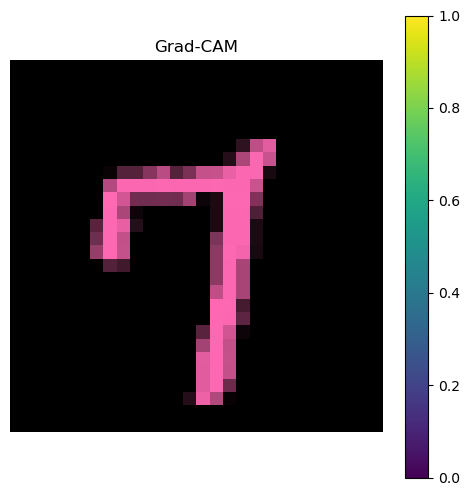

In [61]:
a = x.squeeze(dim=0)
print(a.shape)
a = a.permute(1,2,0)
a = a.cpu().numpy()
a -= a.min()
a /= (a.max() + 1e-8)

plt.figure(figsize=(6,6))
plt.imshow(a, cmap='viridis')
plt.colorbar()
plt.title('Grad-CAM')
plt.axis('off')
plt.show()

In [62]:
alpha = 0.001
steps = 300
target = torch.tensor([3]).to(device)

In [63]:
x_adv = x.clone().to(device).requires_grad_(True)

In [64]:
for step in range(steps):

  s_model.zero_grad()

  logits = s_model(x_adv)
  loss = criterion(logits, target)

  loss.backward()

  with torch.no_grad():
    x_adv -= alpha * x_adv.grad.sign()
    delta = torch.clamp(
            x_adv - x,
            min=-0.1,   #since model was trained with normailzed values
            max=0.1
        )

    x_adv = torch.clamp(
        x + delta,
        min=-1,
        max=1
    )

  x_adv = x_adv.detach()
  x_adv.requires_grad_(True)

  with torch.no_grad():
    probs = torch.softmax(s_model(x_adv), dim=1)
    pred = probs.argmax(dim=1)
    perturb = (x_adv - x).abs().max()

  print(
      f"step={step:03d} "
      f"pred={pred.item()} "
      f"P(3)={probs[0,3]:.4f} "
      f"P(7)={probs[0,7]:.4f}"
  )


step=000 pred=7 P(3)=0.0000 P(7)=0.9994
step=001 pred=7 P(3)=0.0000 P(7)=0.9994
step=002 pred=7 P(3)=0.0000 P(7)=0.9993
step=003 pred=7 P(3)=0.0000 P(7)=0.9993
step=004 pred=7 P(3)=0.0000 P(7)=0.9992
step=005 pred=7 P(3)=0.0000 P(7)=0.9991
step=006 pred=7 P(3)=0.0000 P(7)=0.9990
step=007 pred=7 P(3)=0.0000 P(7)=0.9989
step=008 pred=7 P(3)=0.0000 P(7)=0.9988
step=009 pred=7 P(3)=0.0000 P(7)=0.9986
step=010 pred=7 P(3)=0.0000 P(7)=0.9985
step=011 pred=7 P(3)=0.0000 P(7)=0.9983
step=012 pred=7 P(3)=0.0000 P(7)=0.9981
step=013 pred=7 P(3)=0.0000 P(7)=0.9979
step=014 pred=7 P(3)=0.0000 P(7)=0.9977
step=015 pred=7 P(3)=0.0000 P(7)=0.9975
step=016 pred=7 P(3)=0.0000 P(7)=0.9972
step=017 pred=7 P(3)=0.0000 P(7)=0.9969
step=018 pred=7 P(3)=0.0000 P(7)=0.9966
step=019 pred=7 P(3)=0.0000 P(7)=0.9965
step=020 pred=7 P(3)=0.0000 P(7)=0.9963
step=021 pred=7 P(3)=0.0000 P(7)=0.9961
step=022 pred=7 P(3)=0.0000 P(7)=0.9959
step=023 pred=7 P(3)=0.0000 P(7)=0.9956
step=024 pred=7 P(3)=0.0000 P(7)=0.9953


## Task 6 - Decomposition using SAE

### SAE training and feature identification

In [65]:
from torch import nn

In [66]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [67]:
model3 = Cheater()
model3.load_state_dict(torch.load("./trained_models/CNNmodel_retrained_method2_lr1e-3_lamb0.55.pth"))
model3 = model3.to(device)

In [68]:
class SAE(nn.Module):
  def __init__(self, input_dim=64, hidden_dim=32768):
      super().__init__()

      self.encoder = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU())
      self.decoder = nn.Sequential(nn.Linear(hidden_dim, input_dim))

  def forward(self, x):
    z = self.encoder(x)
    x = self.decoder(z)

    return x, z

In [69]:
sae_model = SAE()
sae_model.to(device)
epochs = 10

In [70]:
def mlp_hook(model, input, output):
  global activ
  activ = output
  return output

In [71]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(sae_model.parameters(), lr=1e-3, weight_decay=0.001)
s1 = model3.classifier[0].register_forward_hook(mlp_hook)
model3.eval()
spar_lambda = 0.001

for epoch in range(epochs):
  for img, label, masks in train_loader:

    _  = model3(img.to(device))

    optimizer.zero_grad()                # zero first
    sae_output, latent = sae_model(activ.detach())  # detach from model's graph
    loss = criterion(sae_output, activ.detach())
    sparsity = latent.abs().mean()
    loss += spar_lambda * sparsity
    loss.backward()
    optimizer.step()                     # step after backward

    print(f"Epoch {epoch}, train loss: {loss.item()}")
torch.save(sae_model.state_dict(), "./trained_models/CNN_sae.pth")

Epoch 0, train loss: 206.88487243652344
Epoch 0, train loss: 7731.5458984375
Epoch 0, train loss: 708.42626953125
Epoch 0, train loss: 1532.7830810546875
Epoch 0, train loss: 3335.68994140625
Epoch 0, train loss: 2774.666259765625
Epoch 0, train loss: 1317.0484619140625
Epoch 0, train loss: 270.4547119140625
Epoch 0, train loss: 179.34228515625
Epoch 0, train loss: 580.4452514648438
Epoch 0, train loss: 1031.998779296875
Epoch 0, train loss: 1077.95947265625
Epoch 0, train loss: 839.9151611328125
Epoch 0, train loss: 530.5505981445312
Epoch 0, train loss: 281.96112060546875
Epoch 0, train loss: 106.52335357666016
Epoch 0, train loss: 55.815696716308594
Epoch 0, train loss: 83.81688690185547
Epoch 0, train loss: 141.1844024658203
Epoch 0, train loss: 200.48402404785156
Epoch 0, train loss: 232.97406005859375
Epoch 0, train loss: 255.2259521484375
Epoch 0, train loss: 228.02586364746094
Epoch 0, train loss: 190.87521362304688
Epoch 0, train loss: 159.6944122314453
Epoch 0, train loss: 11

In [72]:
from collections import Counter
#takes 10 samples of digit 2 from test_loader and finds common features
def top_features_for_digit(digit, num_samples=10, top_k=10):
    model3.eval()
    sae_model.eval()

    samples = []

    with torch.no_grad():
        for img, label, _ in test_loader:
            _ = model3(img.to(device))
            _, latent = sae_model(activ.detach())

            for i in range(latent.size(0)):
                if label[i].item() == digit and len(samples) < num_samples:
                    samples.append(latent[i])

            if len(samples) >= num_samples:
                break

    all_top_features = []

    print(f"Digit {digit} — Top {top_k} features per sample:\n")
    for s, latent in enumerate(samples):
        top = torch.topk(latent, top_k)
        feats = list(zip(top.indices.tolist(), top.values.tolist()))
        print(f"  Sample {s}: {[(idx, round(val, 4)) for idx, val in feats]}")
        all_top_features.extend(top.indices.tolist())

    counts = Counter(all_top_features)
    print(f"\nFeature frequency across {num_samples} samples:")
    for feat, count in counts.most_common():
        print(f"  Feature {feat}: {count}/{num_samples}")

top_features_for_digit(digit=2)

Digit 2 — Top 10 features per sample:

  Sample 0: [(29023, 6.8391), (432, 6.2565), (2657, 6.133), (3478, 6.1177), (14579, 6.0505), (25990, 5.854), (23789, 5.8399), (5362, 5.7805), (32509, 5.7075), (10884, 5.6483)]
  Sample 1: [(29633, 24.4828), (5854, 23.7184), (32108, 21.9032), (10709, 20.419), (26520, 19.8834), (26583, 19.6588), (8154, 19.2141), (1924, 19.1876), (13190, 18.8882), (10762, 18.7717)]
  Sample 2: [(29023, 6.5544), (18937, 6.527), (3478, 5.9452), (14579, 5.8939), (10884, 5.8881), (12753, 5.8696), (10918, 5.7538), (32509, 5.6383), (546, 5.6343), (2657, 5.5986)]
  Sample 3: [(22883, 12.6373), (166, 11.8001), (11115, 11.7949), (29633, 11.4434), (22783, 11.4388), (18260, 11.0358), (152, 10.7464), (26520, 10.6766), (13509, 10.6264), (14030, 10.5882)]
  Sample 4: [(29023, 6.4745), (14579, 5.8341), (546, 5.7947), (32509, 5.7256), (27955, 5.643), (2891, 5.6085), (18937, 5.4216), (3478, 5.3406), (17023, 5.3148), (23789, 5.2593)]
  Sample 5: [(13190, 12.9242), (32108, 11.1524), (2

In [73]:
from collections import Counter

def compare_features_by_color(color, train_digit, test_digit, num_samples=5, top_k=10):
    model3.eval()
    sae_model.eval()

    color_ranges = {
        'orange':    lambda r, g, b: r > g > b,
        'red':       lambda r, g, b: r > g and r > b and g < b + 0.1,
        'blue':      lambda r, g, b: b > r and b > g,
        'green':     lambda r, g, b: g > r and g > b,
        'yellow':    lambda r, g, b: r > b and g > b and abs(r - g) < 0.15,
        'purple':    lambda r, g, b: r > g and b > g and abs(r - b) < 0.2,
        'cyan':      lambda r, g, b: g > r and b > r and g > 0.5 and b > 0.5,
        'hotpink':   lambda r, g, b: r > g and r > b and b > g,
        'brown':     lambda r, g, b: r > g > b and g < 0.3,
        'turquoise': lambda r, g, b: g > r and b > r and g > b,
    }

    check_color = color_ranges[color] if color is not None else None

    def is_target_color(img_tensor, mask_tensor):
        if check_color is None:
            return True
        img = img_tensor.cpu() * 0.5 + 0.5
        mask = mask_tensor.cpu()
        if mask.ndim == 3:
            mask = mask[0]
        mask_bool = mask > 0.5
        if mask_bool.sum() == 0:
            return False
        r = img[0][mask_bool].mean().item()
        g = img[1][mask_bool].mean().item()
        b = img[2][mask_bool].mean().item()
        return check_color(r, g, b)

    def collect_samples(loader, digit, num_samples):
        samples = []
        with torch.no_grad():
            for img, label, masks in loader:
                _ = model3(img.to(device))
                _, latent = sae_model(activ.detach())
                for i in range(img.size(0)):
                    if label[i].item() == digit and is_target_color(img[i], masks[i]):
                        samples.append(latent[i])
                        if len(samples) >= num_samples:
                            return samples
        return samples

    train_samples = collect_samples(train_loader, train_digit, num_samples)
    test_samples = collect_samples(test_loader, test_digit, num_samples)

    print(f"Found {len(train_samples)} {color} '{train_digit}' in train, {len(test_samples)} {color} '{test_digit}' in test\n")

    def get_top_features(samples):
        all_feats = []
        for latent in samples:
            top = torch.topk(latent, top_k)
            all_feats.extend(top.indices.tolist())
        return Counter(all_feats)

    train_counts = get_top_features(train_samples)
    test_counts = get_top_features(test_samples)

    train_set = set(train_counts.keys())
    test_set = set(test_counts.keys())
    common = train_set & test_set

    print(f"Train top features ({train_digit}): {len(train_set)}, Test top features ({test_digit}): {len(test_set)}")
    print(f"Common features: {len(common)}\n")

    print("Common features (feature_id: train_count, test_count):")
    for feat in sorted(common, key=lambda f: train_counts[f] + test_counts[f], reverse=True):
        print(f"  Feature {feat}: train={train_counts[feat]}, test={test_counts[feat]}")

    only_train = train_set - test_set
    only_test = test_set - train_set

    if only_train:
        print(f"\nOnly in train ({train_digit}): {sorted(only_train)}")
    if only_test:
        print(f"\nOnly in test ({test_digit}): {sorted(only_test)}")

    return train_counts, test_counts, common

# usage
train_counts, test_counts, common = compare_features_by_color('orange', train_digit=0, test_digit=2)

Found 5 orange '0' in train, 5 orange '2' in test

Train top features (0): 32, Test top features (2): 36
Common features: 4

Common features (feature_id: train_count, test_count):
  Feature 23789: train=2, test=4
  Feature 13190: train=3, test=2
  Feature 166: train=3, test=1
  Feature 26520: train=1, test=1

Only in train (0): [183, 1522, 5750, 6622, 7116, 8176, 9848, 10838, 11115, 13612, 13750, 14094, 15592, 17152, 18222, 19891, 19973, 20276, 23387, 25170, 25598, 25622, 29868, 30859, 30883, 31640, 32206, 32478]

Only in test (2): [432, 439, 546, 784, 1392, 2657, 2891, 3478, 5362, 5459, 8591, 10528, 11713, 11784, 13509, 14168, 14579, 16595, 17023, 18641, 18937, 19919, 22618, 22783, 25055, 27955, 29023, 29633, 31506, 32108, 32160, 32509]


In [74]:
from collections import Counter

color_map = {
    0: 'orange',
    1: 'red',
    2: 'blue',
    3: 'green',
    4: 'yellow',
    5: 'purple',
    6: 'cyan',
    7: 'hotpink',
    8: 'brown',
    9: 'turquoise',
}

results = {}

for train_digit, color in color_map.items():
    all_common = Counter()
    for test_digit in range(10):
        if train_digit == test_digit:
            continue
        train_counts, test_counts, common = compare_features_by_color(
            color, train_digit=train_digit, test_digit=test_digit, num_samples=5, top_k=10
        )
        for feat in common:
            all_common[feat] += 1  # appeared in how many test_digit comparisons

    results[(color, train_digit)] = dict(all_common.most_common())

# print
for key, feats in results.items():
    print(f"\n{key}: {feats}")

Found 5 orange '0' in train, 5 orange '1' in test

Train top features (0): 32, Test top features (1): 18
Common features: 2

Common features (feature_id: train_count, test_count):
  Feature 13190: train=4, test=4
  Feature 32478: train=5, test=1

Only in train (0): [166, 183, 1522, 2450, 2984, 5750, 6622, 6779, 7116, 8591, 9304, 11395, 11713, 13750, 14094, 14769, 17180, 17936, 18222, 19891, 20487, 25170, 25598, 26520, 27057, 27666, 28765, 28871, 29868, 32206]

Only in test (1): [435, 7393, 10762, 11662, 13509, 16912, 18641, 18904, 22053, 22618, 22783, 22911, 23136, 23333, 26959, 32160]
Found 5 orange '0' in train, 5 orange '2' in test

Train top features (0): 30, Test top features (2): 36
Common features: 4

Common features (feature_id: train_count, test_count):
  Feature 166: train=5, test=1
  Feature 13190: train=1, test=2
  Feature 784: train=1, test=1
  Feature 8591: train=1, test=1

Only in train (0): [1732, 2275, 2984, 7116, 11115, 11395, 11606, 11690, 11998, 12912, 14094, 15592,

In [75]:
results

{('orange', 0): {32478: 5,
  166: 5,
  13190: 4,
  29868: 4,
  6622: 3,
  26520: 3,
  8591: 2,
  23789: 2,
  784: 1,
  17936: 1,
  15592: 1,
  26480: 1,
  26613: 1,
  22883: 1,
  1522: 1,
  11713: 1,
  4256: 1,
  29633: 1,
  7116: 1},
 ('red', 1): {32478: 2, 11998: 1},
 ('blue', 2): {166: 3,
  11998: 3,
  2657: 2,
  25572: 1,
  12912: 1,
  32509: 1,
  18070: 1,
  32478: 1,
  14751: 1},
 ('green', 3): {11998: 2, 32509: 1, 2657: 1},
 ('yellow', 4): {166: 4,
  8591: 4,
  32478: 3,
  1392: 3,
  22911: 2,
  265: 2,
  26520: 1,
  11713: 1,
  32105: 1,
  29868: 1,
  13509: 1,
  25573: 1},
 ('purple', 5): {11998: 5, 26613: 4, 12912: 1, 24335: 1, 15592: 1, 18070: 1},
 ('cyan', 6): {29868: 5,
  32478: 5,
  8591: 4,
  6622: 4,
  4256: 3,
  11713: 2,
  166: 1,
  27553: 1,
  17936: 1,
  24158: 1,
  265: 1,
  32108: 1},
 ('hotpink', 7): {22268: 7,
  265: 2,
  16837: 2,
  32478: 2,
  25572: 1,
  4425: 1,
  1392: 1,
  11998: 1,
  13330: 1,
  18849: 1,
  12782: 1,
  11713: 1,
  32108: 1,
  14168: 1,
  

In [76]:
feature_to_colors = {}

for (color, digit), feat_counts in results.items():
    for feat, count in feat_counts.items():
        if count >= 1:
            if feat not in feature_to_colors:
                feature_to_colors[feat] = []
            feature_to_colors[feat].append((color, digit))

for feat in sorted(feature_to_colors, key=lambda f: len(feature_to_colors[f]), reverse=True):
    print(f"Feature {feat}: {feature_to_colors[feat]} ({len(feature_to_colors[feat])} colors)")

Feature 32478: [('orange', 0), ('red', 1), ('blue', 2), ('yellow', 4), ('cyan', 6), ('hotpink', 7), ('turquoise', 9)] (7 colors)
Feature 166: [('orange', 0), ('blue', 2), ('yellow', 4), ('cyan', 6), ('hotpink', 7), ('turquoise', 9)] (6 colors)
Feature 11998: [('red', 1), ('blue', 2), ('green', 3), ('purple', 5), ('hotpink', 7), ('turquoise', 9)] (6 colors)
Feature 8591: [('orange', 0), ('yellow', 4), ('cyan', 6), ('turquoise', 9)] (4 colors)
Feature 11713: [('orange', 0), ('yellow', 4), ('cyan', 6), ('hotpink', 7)] (4 colors)
Feature 265: [('yellow', 4), ('cyan', 6), ('hotpink', 7), ('turquoise', 9)] (4 colors)
Feature 29868: [('orange', 0), ('yellow', 4), ('cyan', 6)] (3 colors)
Feature 6622: [('orange', 0), ('cyan', 6), ('turquoise', 9)] (3 colors)
Feature 26520: [('orange', 0), ('yellow', 4), ('turquoise', 9)] (3 colors)
Feature 4256: [('orange', 0), ('cyan', 6), ('turquoise', 9)] (3 colors)
Feature 13190: [('orange', 0), ('turquoise', 9)] (2 colors)
Feature 17936: [('orange', 0), (

In [77]:
idx_colour = list(feature_to_colors.keys())

In [78]:
idx_colour

[32478,
 166,
 13190,
 29868,
 6622,
 26520,
 8591,
 23789,
 784,
 17936,
 15592,
 26480,
 26613,
 22883,
 1522,
 11713,
 4256,
 29633,
 7116,
 11998,
 2657,
 25572,
 12912,
 32509,
 18070,
 14751,
 1392,
 22911,
 265,
 32105,
 13509,
 25573,
 24335,
 27553,
 24158,
 32108,
 22268,
 16837,
 4425,
 13330,
 18849,
 12782,
 14168,
 16289,
 24395,
 24339,
 10709,
 28262,
 24968,
 10762,
 27666]

In [79]:
from collections import Counter

def compute_features_by_shape(digit, num_samples=10, top_k=10):
    """
    Collect num_samples of the same digit, find top features for each,
    then count which features appear across samples.
    Features with high frequency = shape features for that digit.
    """
    model3.eval()
    sae_model.eval()

    samples = []
    with torch.no_grad():
        for img, label, masks in train_loader:
            _ = model3(img.to(device))
            _, latent = sae_model(activ.detach())
            for i in range(img.size(0)):
                if label[i].item() == digit:
                    samples.append(latent[i])
                    if len(samples) >= num_samples:
                        break
            if len(samples) >= num_samples:
                break

    print(f"Digit {digit}: collected {len(samples)} samples\n")

    all_feats = Counter()
    for s, latent in enumerate(samples):
        top = torch.topk(latent, top_k)
        feats = list(zip(top.indices.tolist(), top.values.tolist()))
        print(f"  Sample {s}: {[(idx, round(val, 4)) for idx, val in feats]}")
        for idx in top.indices.tolist():
            all_feats[idx] += 1

    print(f"\nFeature frequency across {len(samples)} samples:")
    for feat, count in all_feats.most_common():
        print(f"  Feature {feat}: {count}/{len(samples)}")

    return all_feats


# run for all digits
shape_results = {}
for digit in range(10):
    print(f"\n{'='*50}")
    shape_results[digit] = compute_features_by_shape(digit, num_samples=10, top_k=10)


Digit 0: collected 10 samples

  Sample 0: [(13190, 23.2931), (32478, 20.9367), (13612, 20.4197), (14769, 20.1833), (25170, 18.6415), (26613, 18.1895), (20487, 17.8738), (29868, 17.8103), (7393, 17.7962), (25990, 17.7594)]
  Sample 1: [(166, 25.3376), (18222, 21.1486), (29868, 20.5288), (14094, 20.2542), (15592, 20.2334), (19843, 20.1892), (7116, 20.0035), (23387, 19.9747), (32478, 18.9501), (31640, 18.9238)]
  Sample 2: [(13190, 17.0139), (19973, 16.7353), (7469, 16.4853), (14769, 16.3864), (9563, 16.0709), (25670, 15.9905), (7205, 15.9105), (14094, 15.8059), (27601, 15.7434), (13750, 15.6907)]
  Sample 3: [(13190, 24.3196), (32478, 24.1014), (29868, 21.4544), (18222, 21.451), (26520, 21.31), (166, 20.6897), (31640, 20.32), (29633, 19.8199), (25598, 19.768), (19891, 18.9482)]
  Sample 4: [(29868, 18.4528), (26613, 17.9599), (19678, 17.7718), (25622, 17.5553), (7205, 17.4368), (25670, 17.2423), (8176, 17.1397), (31640, 16.8815), (17152, 16.7504), (20276, 16.5774)]
  Sample 5: [(32478,

In [80]:
shape_results

{0: Counter({32478: 7,
          29868: 6,
          166: 6,
          13190: 5,
          18222: 5,
          14094: 4,
          31640: 4,
          13612: 3,
          26613: 3,
          17152: 3,
          14769: 2,
          19843: 2,
          25670: 2,
          7205: 2,
          26520: 2,
          8176: 2,
          11395: 2,
          26246: 2,
          25170: 1,
          20487: 1,
          7393: 1,
          25990: 1,
          15592: 1,
          7116: 1,
          23387: 1,
          19973: 1,
          7469: 1,
          9563: 1,
          27601: 1,
          13750: 1,
          29633: 1,
          25598: 1,
          19891: 1,
          19678: 1,
          25622: 1,
          20276: 1,
          8546: 1,
          30859: 1,
          455: 1,
          5006: 1,
          11690: 1,
          9175: 1,
          32206: 1,
          1522: 1,
          25060: 1,
          30582: 1,
          24335: 1,
          11998: 1,
          2275: 1,
          12912: 1,
          29

In [81]:
feature_to_digits = {}

for digit, feat_counts in shape_results.items():
    for feat, count in feat_counts.items():
        if count >= 5:
            if feat not in feature_to_digits:
                feature_to_digits[feat] = []
            feature_to_digits[feat].append(digit)

# sort by how many digits share that feature
for feat in sorted(feature_to_digits, key=lambda f: len(feature_to_digits[f]), reverse=True):
    print(f"Feature {feat}: digits {feature_to_digits[feat]} ({len(feature_to_digits[feat])} digits)")

Feature 12912: digits [1, 2, 3, 5, 8] (5 digits)
Feature 30843: digits [1, 2, 3, 8] (4 digits)
Feature 3289: digits [1, 2, 3, 8] (4 digits)
Feature 32478: digits [0, 6, 7] (3 digits)
Feature 29876: digits [1, 5, 8] (3 digits)
Feature 23387: digits [1, 2, 6] (3 digits)
Feature 16932: digits [1, 2, 8] (3 digits)
Feature 21674: digits [2, 3, 8] (3 digits)
Feature 27601: digits [3, 5, 8] (3 digits)
Feature 29868: digits [0, 6] (2 digits)
Feature 166: digits [0, 6] (2 digits)
Feature 11719: digits [1, 8] (2 digits)
Feature 20943: digits [3, 5] (2 digits)
Feature 17180: digits [4, 6] (2 digits)
Feature 15592: digits [5, 8] (2 digits)
Feature 265: digits [7, 9] (2 digits)
Feature 13190: digits [0] (1 digits)
Feature 18222: digits [0] (1 digits)
Feature 8039: digits [1] (1 digits)
Feature 17211: digits [1] (1 digits)
Feature 11574: digits [2] (1 digits)
Feature 2657: digits [2] (1 digits)
Feature 19879: digits [3] (1 digits)
Feature 30054: digits [4] (1 digits)
Feature 11395: digits [4] (1 dig

In [82]:
idx_shape = feature_to_digits.keys()
idx_shape = list(idx_shape)

In [83]:
idx_shape

[13190,
 32478,
 29868,
 166,
 18222,
 12912,
 29876,
 11719,
 30843,
 23387,
 16932,
 8039,
 17211,
 3289,
 21674,
 11574,
 2657,
 27601,
 19879,
 20943,
 17180,
 30054,
 11395,
 22572,
 15592,
 11998,
 26246,
 31741,
 6622,
 8591,
 1522,
 265,
 22268,
 24339,
 12782,
 21036,
 11010,
 18070,
 13904]

In [84]:
filtered_feature_ids = {
    digit: [
        feature
        for feature, freq in feature_counter.items()
        if freq > 3
    ]
    for digit, feature_counter in shape_results.items()
}

# example
print(filtered_feature_ids[0])

[13190, 32478, 29868, 166, 18222, 14094, 31640]


In [85]:
#common neuron between colour and shape
common = set(idx_colour) - set(idx_shape)

In [86]:
common

{784,
 1392,
 4256,
 4425,
 7116,
 10709,
 10762,
 11713,
 13330,
 13509,
 14168,
 14751,
 16289,
 16837,
 17936,
 18849,
 22883,
 22911,
 23789,
 24158,
 24335,
 24395,
 24968,
 25572,
 25573,
 26480,
 26520,
 26613,
 27553,
 27666,
 28262,
 29633,
 32105,
 32108,
 32509}

### Pertubing the features to confirm their representation

In [87]:
# Remove all hooks from every module in the model
for module in model3.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    module._forward_pre_hooks.clear()

#### colour features

In [88]:
DIGIT_COLORS = {
    0: (255, 165,   0),   # Orange
    1: (255,   0,   0),   # Red
    2: (  0,   0, 255),   # Blue
    3: (  0, 200,   0),   # Green
    4: (220, 220,   0),   # Yellow
    5: (128,   0, 128),   # Purple
    6: (  0, 220, 220),   # Cyan
    7: (255, 105, 180),   # Hot Pink
    8: (165,  42,  42),   # Brown
    9: ( 64, 224, 208),   # Turquoise
}

In [89]:
import numpy as np
from collections import defaultdict, Counter
from torch.utils.data import DataLoader

train_subset = train_loader.dataset          # Subset from random_split
train_base   = train_subset.dataset          # original NpzDataset
train_idx    = train_subset.indices

train_imgs   = train_base.images[train_idx]
train_lbls   = train_base.labels[train_idx]
train_masks  = train_base.masks[train_idx]


test_base   = test_loader.dataset

test_imgs   = test_base.images
test_lbls   = test_base.labels
test_masks  = test_base.masks

print("Train samples:", len(train_imgs))
print("Test samples :", len(test_imgs))


def get_color_id(img, mask):
    """
    img  : (28,28,3) uint8 image
    mask : (28,28) binary mask

    Returns the closest predefined digit color.
    """

    # keep only digit pixels
    digit_pixels = img[mask > 0.5]

    if len(digit_pixels) == 0:
        return None

    # brightest pixels best approximate the true fg color
    brightness = digit_pixels.sum(axis=1)
    threshold = np.percentile(brightness, 90)

    top_pixels = digit_pixels[brightness >= threshold]

    estimated_color = top_pixels.mean(axis=0)

    best_color = None
    best_dist = float("inf")

    for cid, rgb in DIGIT_COLORS.items():
        dist = np.linalg.norm(
            estimated_color - np.array(rgb)
        )

        if dist < best_dist:
            best_dist = dist
            best_color = cid

    return best_color


train_by_color = defaultdict(list)
test_by_color  = defaultdict(list)

print("\nRecovering train colors...")
for i in range(len(train_imgs)):
    c = get_color_id(train_imgs[i], train_masks[i])
    if c is not None:
        train_by_color[c].append(i)

print("Recovering test colors...")
for i in range(len(test_imgs)):
    c = get_color_id(test_imgs[i], test_masks[i])
    if c is not None:
        test_by_color[c].append(i)


print("\nRecovered color counts")
for c in range(10):
    print(
        f"Color {c}: "
        f"train={len(train_by_color[c])}   "
        f"test={len(test_by_color[c])}"
    )


rng = np.random.default_rng(42)

color_datasets = {}
color_loaders  = {}

for color in range(10):

    print("\n" + "="*60)
    print(f"COLOR {color}")

    # ----- random 100 train samples -----
    available_train = train_by_color[color]

    n = min(100, len(available_train))

    chosen_train = rng.choice(
        available_train,
        size=n,
        replace=False
    )
    # print(chosen_train)
    # ----- all test samples -----
    chosen_test = test_by_color[color]

    # ----- combine -----
    images = np.concatenate([
        train_imgs[chosen_train],
        test_imgs[chosen_test]
    ])

    labels = np.concatenate([
        train_lbls[chosen_train],
        test_lbls[chosen_test]
    ])

    masks = np.concatenate([
        train_masks[chosen_train],
        test_masks[chosen_test]
    ])

    # ----- create dataset -----
    ds = NpzDataset(
        images=images,
        labels=labels,
        masks=masks,
        transform=tf
    )

    color_datasets[color] = ds

    # ----- create loader -----
    color_loaders[color] = DataLoader(
        ds,
        batch_size=256,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    print(f"Selected train : {len(chosen_train)}")
    print(f"Selected test  : {len(chosen_test)}")
    print(f"Total samples  : {len(ds)}")

    counts = Counter(labels.tolist())

    print("\nDigit distribution:")
    for d in range(10):
        print(f"digit {d}: {counts[d]}")


Train samples: 45600
Test samples : 3000

Recovering train colors...
Recovering test colors...

Recovered color counts
Color 0: train=4489   test=303
Color 1: train=5122   test=291
Color 2: train=4515   test=297
Color 3: train=4703   test=291
Color 4: train=4465   test=300
Color 5: train=4117   test=299
Color 6: train=4511   test=312
Color 7: train=4794   test=310
Color 8: train=4403   test=295
Color 9: train=4481   test=302

COLOR 0
Selected train : 100
Selected test  : 303
Total samples  : 403

Digit distribution:
digit 0: 100
digit 1: 41
digit 2: 34
digit 3: 32
digit 4: 33
digit 5: 22
digit 6: 36
digit 7: 43
digit 8: 32
digit 9: 30

COLOR 1
Selected train : 100
Selected test  : 291
Total samples  : 391

Digit distribution:
digit 0: 31
digit 1: 100
digit 2: 30
digit 3: 32
digit 4: 40
digit 5: 26
digit 6: 31
digit 7: 36
digit 8: 32
digit 9: 33

COLOR 2
Selected train : 100
Selected test  : 297
Total samples  : 397

Digit distribution:
digit 0: 35
digit 1: 28
digit 2: 100
digit 3: 40
d

In [90]:
model4 = Cheater()
model4.load_state_dict(torch.load("./trained_models/CNNmodel_retrained_method2_lr1e-3_lamb0.55.pth"))
model4 = model4.to(device)

In [91]:
sae_model = SAE()
sae_model.load_state_dict(torch.load("./trained_models/CNN_sae.pth"))
sae_model = sae_model.to(device)

In [92]:
color_loaders

{0: <torch.utils.data.dataloader.DataLoader at 0x732ff01268b0>,
 1: <torch.utils.data.dataloader.DataLoader at 0x733003f3cc30>,
 2: <torch.utils.data.dataloader.DataLoader at 0x73324f934dd0>,
 3: <torch.utils.data.dataloader.DataLoader at 0x73324f970270>,
 4: <torch.utils.data.dataloader.DataLoader at 0x732fe82897b0>,
 5: <torch.utils.data.dataloader.DataLoader at 0x732fe8289f20>,
 6: <torch.utils.data.dataloader.DataLoader at 0x732fe828a360>,
 7: <torch.utils.data.dataloader.DataLoader at 0x732fe828a580>,
 8: <torch.utils.data.dataloader.DataLoader at 0x732fe828a690>,
 9: <torch.utils.data.dataloader.DataLoader at 0x732fe828a7a0>}

In [93]:
model4.eval()
sae_model.eval()

SAE(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=32768, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32768, out_features=64, bias=True)
  )
)

In [94]:
# model.load_state_dict(torch.load('/content/drive/MyDrive/CNNmodel_retrained.pth'))
# model = model.to(device)
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
def test(model, test_loader):

    model.eval()

    total_loss = 0
    total_correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels, masks in test_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)

            total_loss += criterion(logits, labels).item() * imgs.size(0)
            total_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()

            all_preds.append(
                logits.argmax(dim=1).cpu()
            )
            all_labels.append(
                labels.cpu()
            )

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    n = len(labels)

    overall_loss = total_loss / n
    overall_acc = total_correct / n

    per_class_acc = {}

    for digit in range(10):

        class_mask = (labels == digit)

        if class_mask.sum() > 0:
            per_class_acc[digit] = (
                (preds[class_mask] ==
                 labels[class_mask])
                .float()
                .mean()
                .item()
            )
        else:
            per_class_acc[digit] = 0.0


    conf_matrix = torch.zeros(
        10,
        10,
        dtype=torch.long
    )

    for t, p in zip(labels.view(-1), preds.view(-1)):
        conf_matrix[t.long(), p.long()] += 1

    print(
        f'\nTest loss: {overall_loss:.4f}'
        f' | Test accuracy: {overall_acc:.4f}\n'
    )

    print('Per-class accuracy:')

    for digit, acc in per_class_acc.items():

        bar = '█' * int(acc * 20)

        print(
            f'  Digit {digit}: '
            f'{acc:.4f} {bar}'
        )

    print('\nConfusion matrix (rows=true, cols=pred):')

    header = '       ' + '  '.join(
        f'{i:>4}' for i in range(10)
    )
    print(header)

    for i, row in enumerate(conf_matrix):
        print(
            f' [{i}]  ' +
            '  '.join(
                f'{v:>4}'
                for v in row.tolist()
            )
        )

    return {
        'loss': overall_loss,
        'accuracy': overall_acc,
        'per_class_acc': per_class_acc,
        'conf_matrix': conf_matrix,
    }

In [95]:
# to get the original model classifier 0 output
def patching(idx):
  def classifier0_hook(model4, input, output):
    sae_latent = sae_model.encoder(output)
    for i in idx:
      sae_latent[:,i] = 0
    sae_out = sae_model.decoder(sae_latent)
    return sae_out
  return classifier0_hook

In [96]:
import multiprocessing as mp
mp.set_start_method('fork', force=True)

In [97]:
import csv

log_path = "./logs/perturbation_colour_logs.csv"

with open(log_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "color", "stage",
        "loss", "accuracy",
        "acc_digit_0", "acc_digit_1", "acc_digit_2", "acc_digit_3", "acc_digit_4",
        "acc_digit_5", "acc_digit_6", "acc_digit_7", "acc_digit_8", "acc_digit_9"
    ])

for i in range(10):
    # baseline results
    print(f"\n{'='*60}")
    print(f"COLOR {i} — BASELINE")
    results = test(model4, color_loaders[i])

    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            i, "baseline",
            f"{results['loss']:.6f}", f"{results['accuracy']:.6f}",
            *[f"{results['per_class_acc'][d]:.6f}" for d in range(10)]
        ])

    print("=============================================================")

    # result after perturbation
    print(f"COLOR {i} — AFTER PERTURBATION")
    m = model4.classifier[0].register_forward_hook(patching(idx_colour))
    results = test(model4, color_loaders[i])

    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            i, "perturbed",
            f"{results['loss']:.6f}", f"{results['accuracy']:.6f}",
            *[f"{results['per_class_acc'][d]:.6f}" for d in range(10)]
        ])

    m.remove()

print(f"\nLogs saved to {log_path}")


COLOR 0 — BASELINE

Test loss: 7.4035 | Test accuracy: 0.4342

Per-class accuracy:
  Digit 0: 0.9800 ███████████████████
  Digit 1: 0.0000 
  Digit 2: 0.0294 
  Digit 3: 0.0000 
  Digit 4: 0.0000 
  Digit 5: 0.0000 
  Digit 6: 0.5278 ██████████
  Digit 7: 1.0000 ████████████████████
  Digit 8: 0.0000 
  Digit 9: 0.4667 █████████

Confusion matrix (rows=true, cols=pred):
          0     1     2     3     4     5     6     7     8     9
 [0]    98     0     0     0     0     0     0     1     0     1
 [1]     1     0     1     0     0     0     0    39     0     0
 [2]    13     0     1     0     0     0     4    16     0     0
 [3]    12     0     1     0     0     0     1    14     0     4
 [4]     2     0     0     0     0     0     1    17     0    13
 [5]     4     0     0     0     0     0     2    10     0     6
 [6]    14     0     0     0     0     0    19     0     0     3
 [7]     0     0     0     0     0     0     0    43     0     0
 [8]     4     0     0     0     0     0

In [98]:
import numpy as np
from collections import defaultdict, Counter
from torch.utils.data import DataLoader


train_subset = train_loader.dataset      # Subset from random_split
train_base   = train_subset.dataset      # original NpzDataset
train_idx    = train_subset.indices

train_imgs   = train_base.images[train_idx]
train_lbls   = train_base.labels[train_idx]
train_masks  = train_base.masks[train_idx]


test_base   = test_loader.dataset

test_imgs   = test_base.images
test_lbls   = test_base.labels
test_masks  = test_base.masks

print("Train samples:", len(train_imgs))
print("Test samples :", len(test_imgs))


train_by_digit = defaultdict(list)
test_by_digit  = defaultdict(list)

for i, lbl in enumerate(train_lbls):
    train_by_digit[int(lbl)].append(i)

for i, lbl in enumerate(test_lbls):
    test_by_digit[int(lbl)].append(i)

print("\nDigit counts:")
for d in range(10):
    print(
        f"Digit {d}: "
        f"train={len(train_by_digit[d])}   "
        f"test={len(test_by_digit[d])}"
    )


rng = np.random.default_rng(42)

digit_datasets = {}
digit_loaders  = {}

for digit in range(10):

    print("\n" + "="*60)
    print(f"DIGIT {digit}")

    # ----- random 100 train samples -----
    available_train = train_by_digit[digit]

    chosen_train = rng.choice(
        available_train,
        size=min(100, len(available_train)),
        replace=False
    )

    # ----- all test samples -----
    chosen_test = test_by_digit[digit]

    # ----- combine -----
    images = np.concatenate([
        train_imgs[chosen_train],
        test_imgs[chosen_test]
    ])

    labels = np.concatenate([
        train_lbls[chosen_train],
        test_lbls[chosen_test]
    ])

    masks = np.concatenate([
        train_masks[chosen_train],
        test_masks[chosen_test]
    ])

    # ----- create dataset -----
    ds = NpzDataset(
        images=images,
        labels=labels,
        masks=masks,
        transform=tf
    )

    digit_datasets[digit] = ds

    # ----- create loader -----
    digit_loaders[digit] = DataLoader(
        ds,
        batch_size=256,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    print(f"Selected train : {len(chosen_train)}")
    print(f"Selected test  : {len(chosen_test)}")
    print(f"Total samples  : {len(ds)}")

    counts = Counter(labels.tolist())
    print("Digit distribution:", dict(counts))


Train samples: 45600
Test samples : 3000

Digit counts:
Digit 0: train=4489   test=296
Digit 1: train=5122   test=337
Digit 2: train=4515   test=298
Digit 3: train=4703   test=307
Digit 4: train=4465   test=292
Digit 5: train=4117   test=271
Digit 6: train=4511   test=296
Digit 7: train=4794   test=313
Digit 8: train=4403   test=293
Digit 9: train=4481   test=297

DIGIT 0
Selected train : 100
Selected test  : 296
Total samples  : 396
Digit distribution: {0: 396}

DIGIT 1
Selected train : 100
Selected test  : 337
Total samples  : 437
Digit distribution: {1: 437}

DIGIT 2
Selected train : 100
Selected test  : 298
Total samples  : 398
Digit distribution: {2: 398}

DIGIT 3
Selected train : 100
Selected test  : 307
Total samples  : 407
Digit distribution: {3: 407}

DIGIT 4
Selected train : 100
Selected test  : 292
Total samples  : 392
Digit distribution: {4: 392}

DIGIT 5
Selected train : 100
Selected test  : 271
Total samples  : 371
Digit distribution: {5: 371}

DIGIT 6
Selected train : 10

In [99]:
model5 = Cheater()
model5.load_state_dict(torch.load("./trained_models/CNNmodel_retrained_method2_lr1e-3_lamb0.55.pth"))
model5 = model5.to(device)

In [100]:
sae_model = SAE()
sae_model.load_state_dict(torch.load("./trained_models/CNN_sae.pth"))
sae_model = sae_model.to(device)

In [101]:
model5.eval()
sae_model.eval()

SAE(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=32768, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32768, out_features=64, bias=True)
  )
)

In [102]:
# model.load_state_dict(torch.load('/content/drive/MyDrive/CNNmodel_retrained.pth'))
# model = model.to(device)
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
def test(model, test_loader):

    model.eval()

    total_loss = 0
    total_correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels, masks in test_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)

            total_loss += criterion(logits, labels).item() * imgs.size(0)
            total_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()

            all_preds.append(
                logits.argmax(dim=1).cpu()
            )
            all_labels.append(
                labels.cpu()
            )

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    n = len(labels)

    overall_loss = total_loss / n
    overall_acc = total_correct / n

    per_class_acc = {}

    for digit in range(10):

        class_mask = (labels == digit)

        if class_mask.sum() > 0:
            per_class_acc[digit] = (
                (preds[class_mask] ==
                 labels[class_mask])
                .float()
                .mean()
                .item()
            )
        else:
            per_class_acc[digit] = 0.0


    conf_matrix = torch.zeros(
        10,
        10,
        dtype=torch.long
    )

    for t, p in zip(labels.view(-1), preds.view(-1)):
        conf_matrix[t.long(), p.long()] += 1

    print(
        f'\nTest loss: {overall_loss:.4f}'
        f' | Test accuracy: {overall_acc:.4f}\n'
    )

    print('Per-class accuracy:')

    for digit, acc in per_class_acc.items():

        bar = '█' * int(acc * 20)

        print(
            f'  Digit {digit}: '
            f'{acc:.4f} {bar}'
        )

    print('\nConfusion matrix (rows=true, cols=pred):')

    header = '       ' + '  '.join(
        f'{i:>4}' for i in range(10)
    )
    print(header)

    for i, row in enumerate(conf_matrix):
        print(
            f' [{i}]  ' +
            '  '.join(
                f'{v:>4}'
                for v in row.tolist()
            )
        )

    return {
        'loss': overall_loss,
        'accuracy': overall_acc,
        'per_class_acc': per_class_acc,
        'conf_matrix': conf_matrix,
    }

In [103]:
# to get the original model classifier 0 output
def patching(idx):
  def classifier0_hook(model5, input, output):
    sae_latent = sae_model.encoder(output)
    for i in idx:
      sae_latent[:,i] = 0
    sae_out = sae_model.decoder(sae_latent)
    return sae_out
  return classifier0_hook

In [104]:
import csv

log_path = "./logs/perturbation_shapes_logs.csv"

with open(log_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "digit", "stage",
        "loss", "accuracy",
        "acc_digit_0", "acc_digit_1", "acc_digit_2", "acc_digit_3", "acc_digit_4",
        "acc_digit_5", "acc_digit_6", "acc_digit_7", "acc_digit_8", "acc_digit_9"
    ])

for i in range(10):
    # baseline results
    print(f"\n{'='*60}")
    print(f"COLOR {i} — BASELINE")
    results = test(model5, color_loaders[i])

    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            i, "baseline",
            f"{results['loss']:.6f}", f"{results['accuracy']:.6f}",
            *[f"{results['per_class_acc'][d]:.6f}" for d in range(10)]
        ])

    print("=============================================================")

    # result after perturbation
    print(f"COLOR {i} — AFTER PERTURBATION")
    m = model5.classifier[0].register_forward_hook(patching(filtered_feature_ids[i]))
    results = test(model5, color_loaders[i])

    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            i, "perturbed",
            f"{results['loss']:.6f}", f"{results['accuracy']:.6f}",
            *[f"{results['per_class_acc'][d]:.6f}" for d in range(10)]
        ])

    m.remove()

print(f"\nLogs saved to {log_path}")


COLOR 0 — BASELINE

Test loss: 7.4035 | Test accuracy: 0.4342

Per-class accuracy:
  Digit 0: 0.9800 ███████████████████
  Digit 1: 0.0000 
  Digit 2: 0.0294 
  Digit 3: 0.0000 
  Digit 4: 0.0000 
  Digit 5: 0.0000 
  Digit 6: 0.5278 ██████████
  Digit 7: 1.0000 ████████████████████
  Digit 8: 0.0000 
  Digit 9: 0.4667 █████████

Confusion matrix (rows=true, cols=pred):
          0     1     2     3     4     5     6     7     8     9
 [0]    98     0     0     0     0     0     0     1     0     1
 [1]     1     0     1     0     0     0     0    39     0     0
 [2]    13     0     1     0     0     0     4    16     0     0
 [3]    12     0     1     0     0     0     1    14     0     4
 [4]     2     0     0     0     0     0     1    17     0    13
 [5]     4     0     0     0     0     0     2    10     0     6
 [6]    14     0     0     0     0     0    19     0     0     3
 [7]     0     0     0     0     0     0     0    43     0     0
 [8]     4     0     0     0     0     0